# Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.api as tsa

In [3]:
PLOT_SIZE = (10, 6)
PLOT_SIZE_X = PLOT_SIZE[0]
PLOT_SIZE_Y = PLOT_SIZE[1]

In [4]:
def general_plot(data, file, xlabel=None, ylabel=None, title=None, save_file=False):
    fig, ax = plt.subplots(figsize=PLOT_SIZE)
    sns.set_style("whitegrid")
    ax.plot(data.dropna(), color="black")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if save_file:
        fig.savefig(
            file,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )   
    plt.show()

def decomp_plot(data, file, model="additive", save_file=False):
    decomp_result = tsa.seasonal_decompose(data.dropna(), model=model)
    fig = decomp_result.plot()
    fig.set_size_inches(PLOT_SIZE_X, PLOT_SIZE_Y)
    axes = fig.get_axes()

    for ax in axes:
        for line in ax.get_lines():
            line.set_color("black")
    
    axes[3].get_lines()[1].set_color("black")

    axes[0].set_title(None)
    axes[0].set_ylabel("Szereg czasowy")
    axes[1].set_ylabel("Trend")
    axes[2].set_ylabel("Sezonowość")
    axes[3].set_ylabel("Reszty")
    if save_file:
        fig.savefig(
            file,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )
    plt.show()

def structure_plot(x, *args, labels, colors, file, save_file, title=None, xlabel=None, ylabel=None):
    fig, ax = plt.subplots(figsize=PLOT_SIZE)

    ax.stackplot(x, *args,
                labels=labels,
                colors=colors,
                alpha=0.85)

    ax.set_ylim(0, 100)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend(loc="upper left")
    plt.tight_layout()
    if save_file:
        fig.savefig(
            file,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )   
    plt.show()

In [5]:
monthly_data = pd.read_excel("../data/dane.xlsx", sheet_name="miesięczne", parse_dates=["data"], index_col="data")
quarterly_data = pd.read_excel("../data/dane.xlsx", sheet_name="kwartalne", parse_dates=["data"], index_col="data")
yearly_data = pd.read_excel("../data/dane.xlsx", sheet_name="roczne", parse_dates=["data"], index_col="data")

for col in monthly_data.columns:
    monthly_data[col] = monthly_data[col].asfreq("MS")

for col in quarterly_data.columns:
    quarterly_data[col] = quarterly_data[col].asfreq("QS")

for col in yearly_data.columns:
    yearly_data[col] = yearly_data[col].asfreq("YS")

monthly_data["tk_tow_lad_dyn"] = monthly_data["tk_tow_prac_przew"] / monthly_data["tk_tow_prac_eksp"]
monthly_data["tk_tow_masa_jedn"] = monthly_data["tk_tow_masa"] / monthly_data["tk_tow_prac_eksp"]
quarterly_data["tk_tow_int_tran"] = monthly_data["tk_tow_prac_przew"].resample("QS").sum().div(quarterly_data["pkb"])

monthly_data["tk_pas_lad_dyn"] = monthly_data["tk_pas_prac_przew"] / monthly_data["tk_pas_prac_eksp"]
quarterly_data["tk_pas_int_tran"] = monthly_data["tk_pas_prac_przew"].resample("QS").sum().div(quarterly_data["pkb"])

quarterly_data["td_tow_lad_dyn"] = quarterly_data["td_tow_prac_przew"] / quarterly_data["td_tow_prac_eksp"]
quarterly_data["td_tow_masa_jedn"] = quarterly_data["td_tow_masa"] / quarterly_data["td_tow_prac_eksp"]
quarterly_data["td_tow_int_tran"] = quarterly_data["td_tow_prac_przew"] / quarterly_data["pkb"]

yearly_data["ink_lin_dwu_el_udzial"] = yearly_data["ink_lin_dwu_el"] / yearly_data["ink_lin_eksp"] * 100
yearly_data["ink_wyd_ut_udzial"] = yearly_data["ink_wyd_ut"] / (yearly_data["ink_wyd_ut"] + yearly_data["ink_wyd_inw"]) * 100
yearly_data["ink_wyd_inw_udzial"] = yearly_data["ink_wyd_inw"] / (yearly_data["ink_wyd_ut"] + yearly_data["ink_wyd_inw"]) * 100
yearly_data["ind_pub_bez_aut_de"] = yearly_data["ind_pub_bez_aut"] - yearly_data["ind_drog_ekspr"]
yearly_data["ind_wyd_ut_udzial"] = yearly_data["ind_wyd_ut"] / (yearly_data["ind_wyd_ut"] + yearly_data["ind_wyd_inw"]) * 100
yearly_data["ind_wyd_inw_udzial"] = yearly_data["ind_wyd_inw"] / (yearly_data["ind_wyd_ut"] + yearly_data["ind_wyd_inw"]) * 100

yearly_data["env_emis_td_udzial"] = yearly_data["env_emis_td"] / yearly_data["env_emis_og"] * 100
yearly_data["env_emis_tk_udzial"] = yearly_data["env_emis_tk"] / yearly_data["env_emis_og"] * 100
yearly_data["env_emis_poz_udzial"] = (yearly_data["env_emis_og"] - yearly_data["env_emis_td"] - yearly_data["env_emis_tk"]) / yearly_data["env_emis_og"] * 100
yearly_data["env_emis_tk_masa"] = yearly_data["env_emis_tk"] / monthly_data["tk_tow_masa"].resample("YS").sum()
yearly_data["env_emis_tk_prac_przew"] = yearly_data["env_emis_tk"] / monthly_data["tk_tow_prac_przew"].resample("YS").sum()
yearly_data["env_emis_td_masa"] = yearly_data["env_emis_td"] / quarterly_data["td_tow_masa"].resample("YS").sum()
yearly_data["env_emis_td_prac_przew"] = yearly_data["env_emis_td"] / quarterly_data["td_tow_prac_przew"].resample("YS").sum()

# Transport kolejowy towarowy

## Masa towarów w transporcie kolejowym

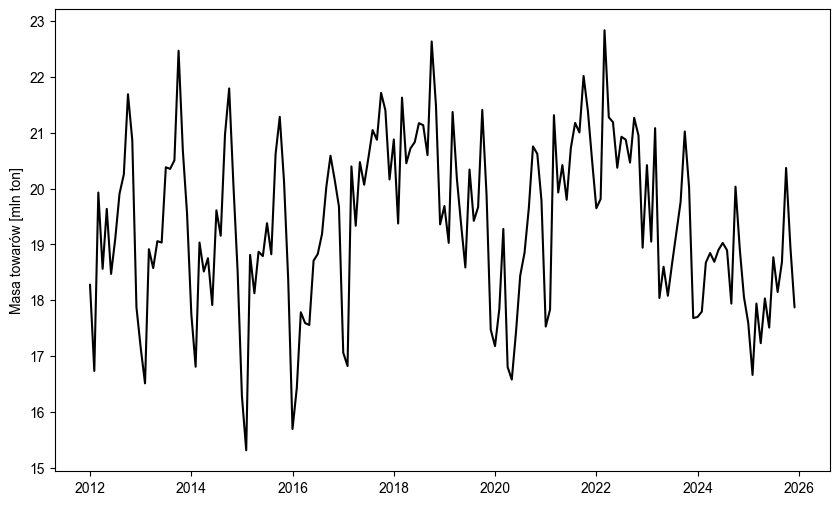

In [6]:
general_plot(
    monthly_data["tk_tow_masa"],
    file="../figures/tk_tow_masa.png",
    ylabel="Masa towarów [mln ton]",
    title=None,
    save_file=False
)

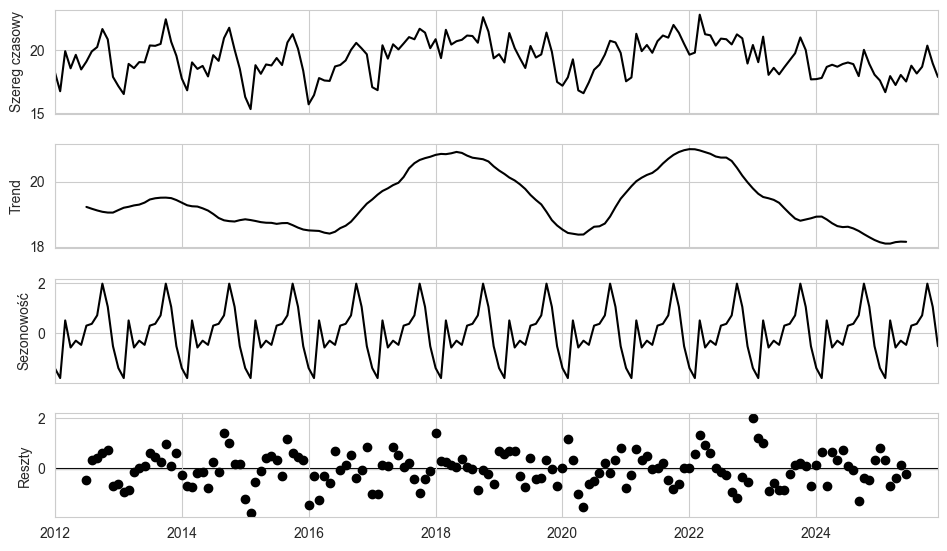

In [7]:
decomp_plot(
    monthly_data["tk_tow_masa"],
    file="../figures/tk_tow_masa_decomp.png",
    save_file=False
)


## Praca przewozowa w transporcie kolejowym towarowym

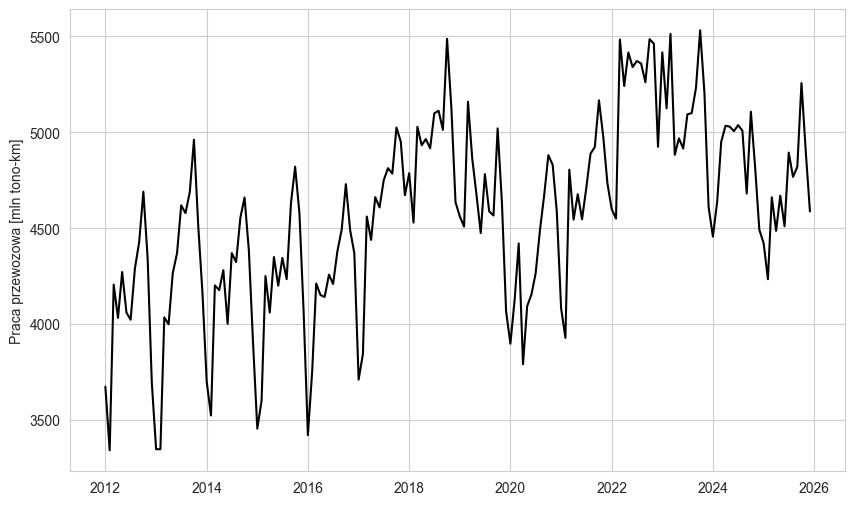

In [8]:
general_plot(
    monthly_data["tk_tow_prac_przew"],
    file="../figures/tk_tow_prac_przew.png",
    ylabel="Praca przewozowa [mln tono-km]",
    title=None,
    save_file=False
)

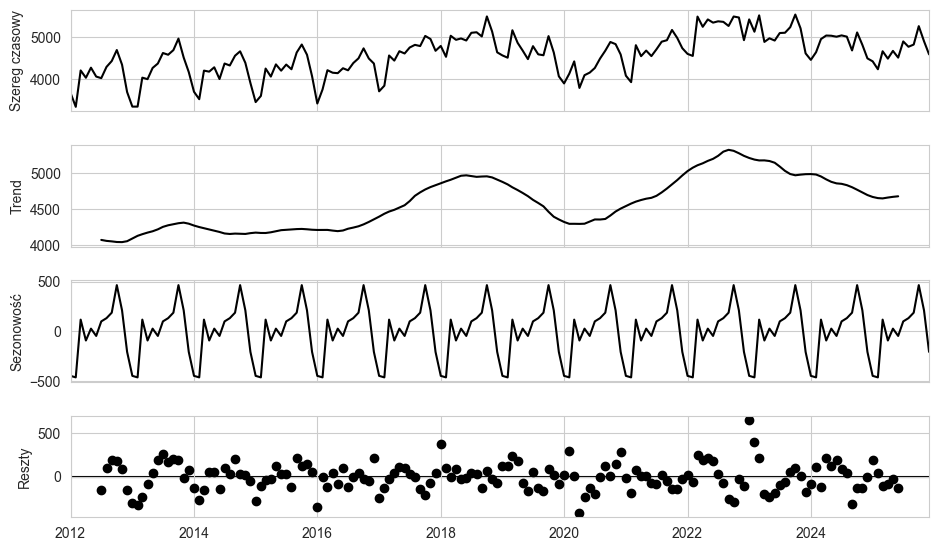

In [9]:
decomp_plot(
    monthly_data["tk_tow_prac_przew"],
    file="../figures/tk_tow_prac_przew_decomp.png",
    save_file=False
)

## Praca eksploatacyjna w transporcie kolejowym towarowym

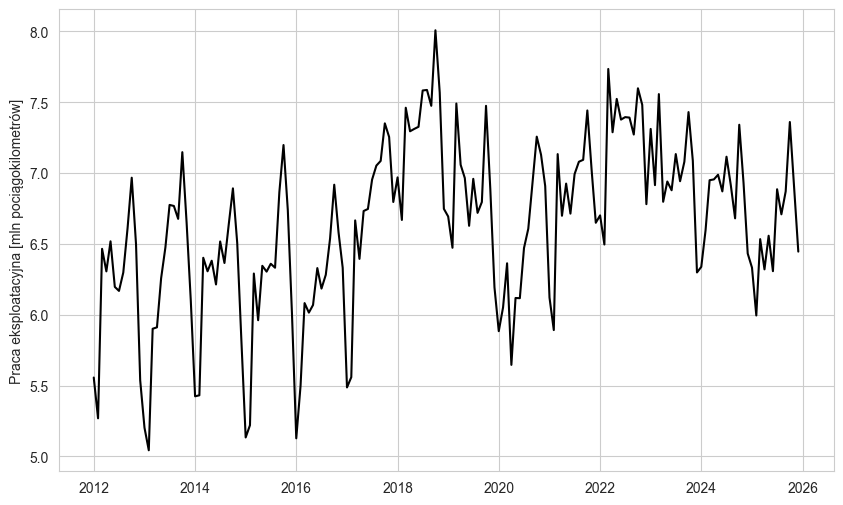

In [10]:
general_plot(
    monthly_data["tk_tow_prac_eksp"],
    file="../figures/tk_tow_prac_eksp.png",
    ylabel="Praca eksploatacyjna [mln pociągokilometrów]",
    title=None,
    save_file=False
)

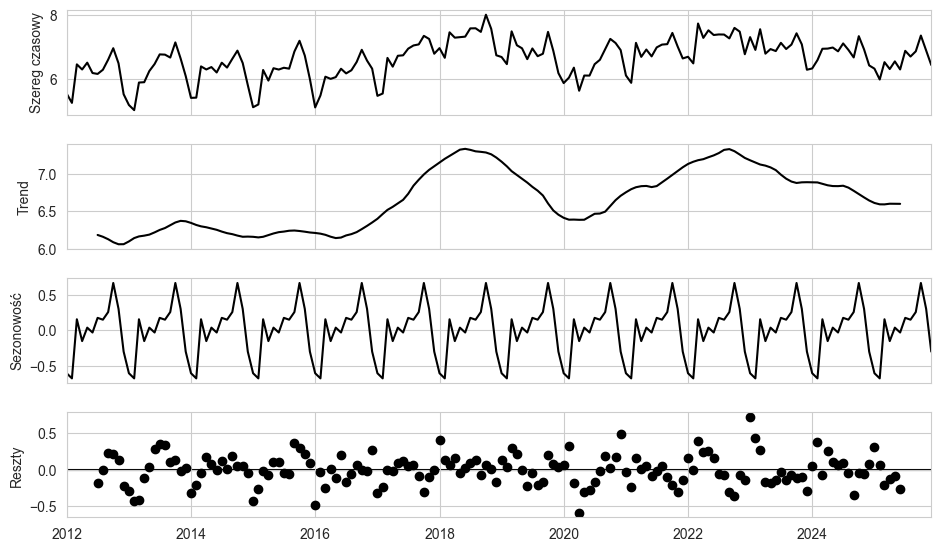

In [11]:
decomp_plot(
    monthly_data["tk_tow_prac_eksp"],
    file="../figures/tk_tow_prac_eksp_decomp.png",
    save_file=False
)

## Ładowność dynamiczna w transporcie kolejowym towarowym

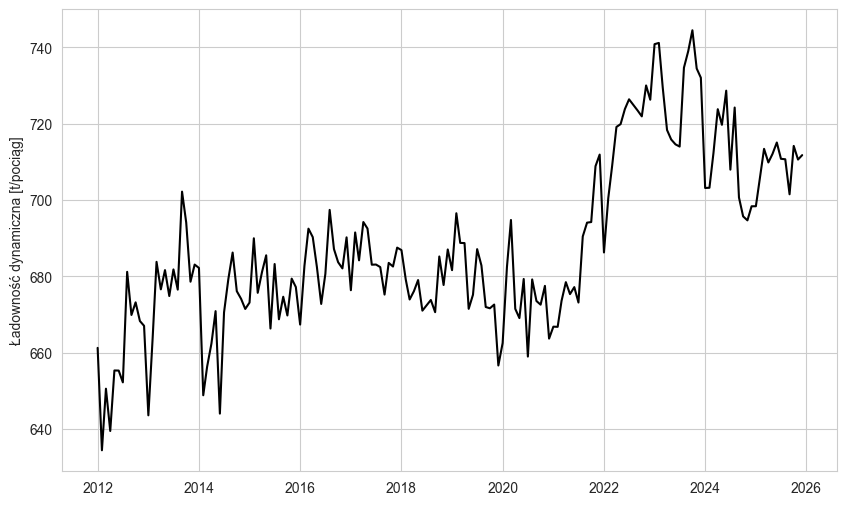

In [12]:
general_plot(
    monthly_data["tk_tow_lad_dyn"],
    file="../figures/tk_tow_lad_dyn.png",
    ylabel="Ładowność dynamiczna [t/pociąg]",
    title=None,
    save_file=False
)

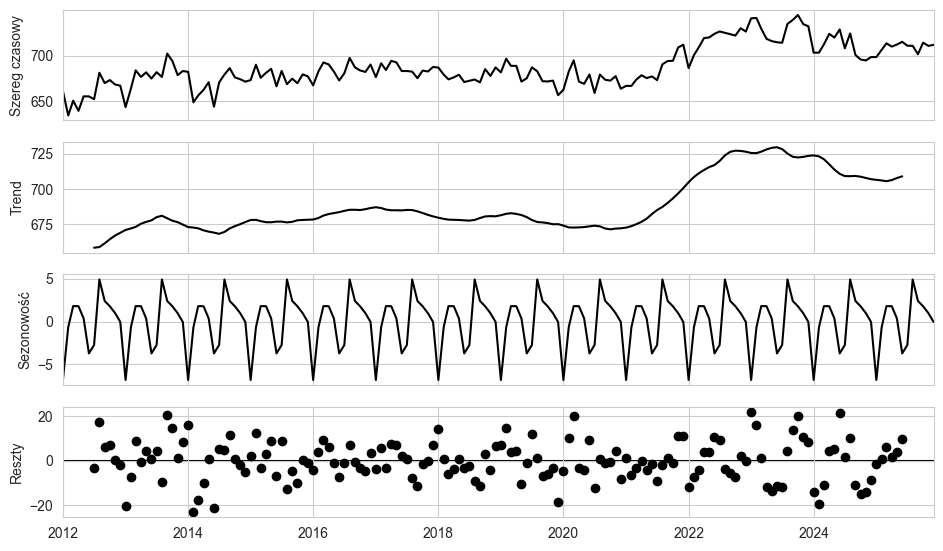

In [13]:
decomp_plot(
    monthly_data["tk_tow_lad_dyn"],
    file="../figures/tk_tow_lad_dyn_decomp.png",
    save_file=False
)

## Masa jednostkowa w transporcie kolejowym

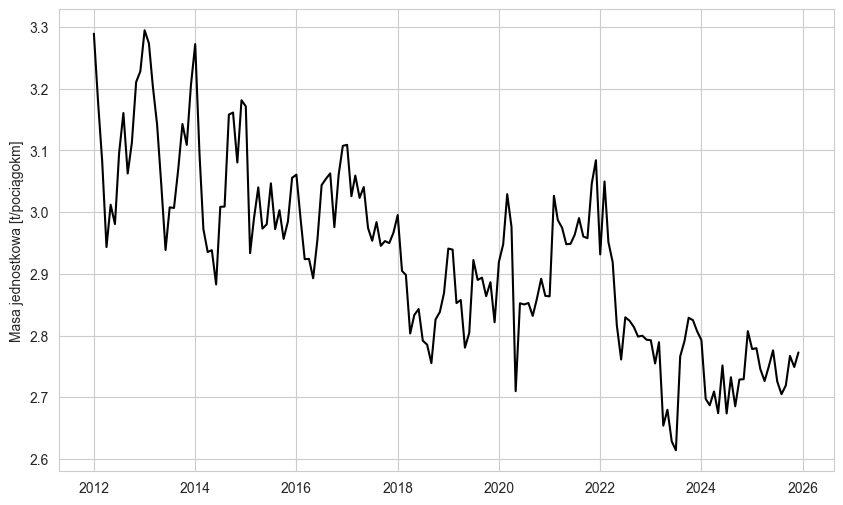

In [14]:
general_plot(
    monthly_data["tk_tow_masa_jedn"],
    file="../figures/tk_tow_masa_jedn.png",
    ylabel="Masa jednostkowa [t/pociągokm]",
    title=None,
    save_file=False
)

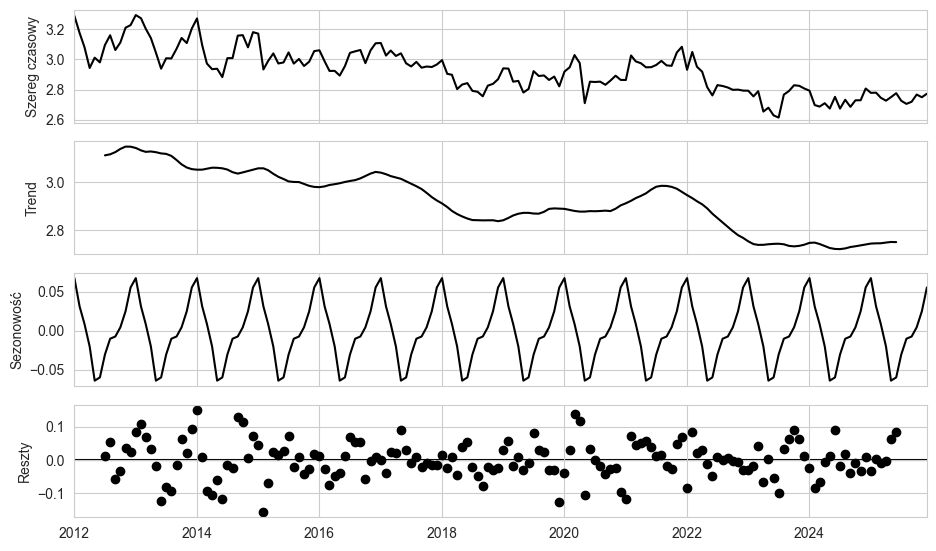

In [15]:
decomp_plot(
    monthly_data["tk_tow_masa_jedn"],
    file="../figures/tk_tow_masa_jedn_decomp.png",
    save_file=False
)

## Intensywność transportowa

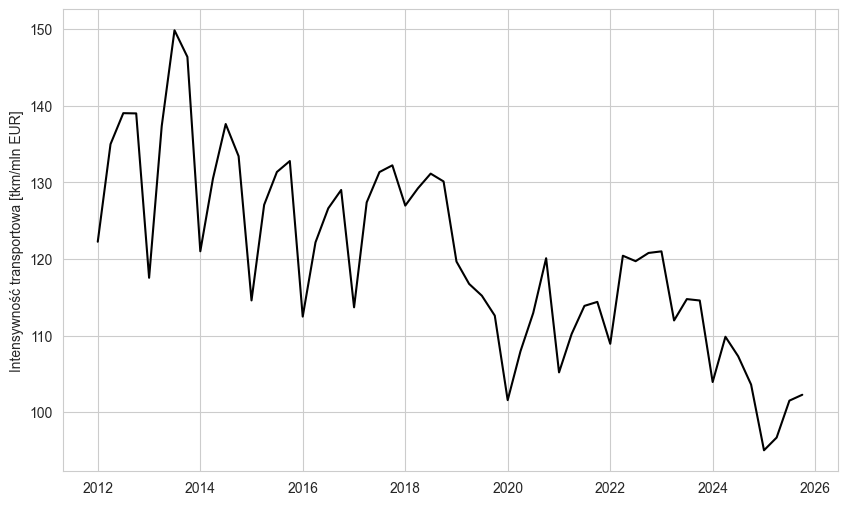

In [16]:
general_plot(
    quarterly_data["tk_tow_int_tran"],
    file="../figures/tk_tow_int_tran.png",
    ylabel="Intensywność transportowa [tkm/mln EUR]",
    title=None,
    save_file=False
)

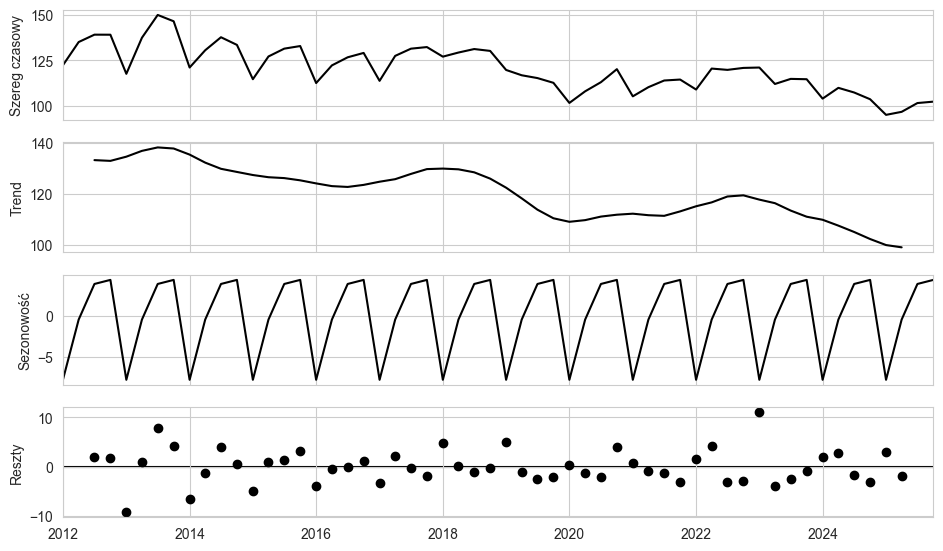

In [17]:
decomp_plot(
    quarterly_data["tk_tow_int_tran"],
    file="../figures/tk_tow_int_tran_decomp.png",
    save_file=False
)

# Transport kolejowy pasażerski

## Liczba pasażerów

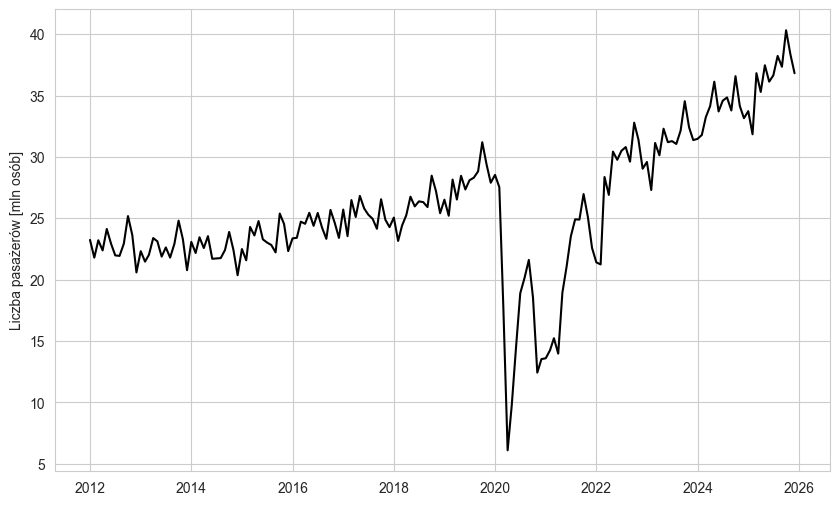

In [18]:
general_plot(
    monthly_data["tk_pas_liczba"],
    file="../figures/tk_pas_liczba.png",
    ylabel="Liczba pasażerów [mln osób]",
    title=None,
    save_file=False
)

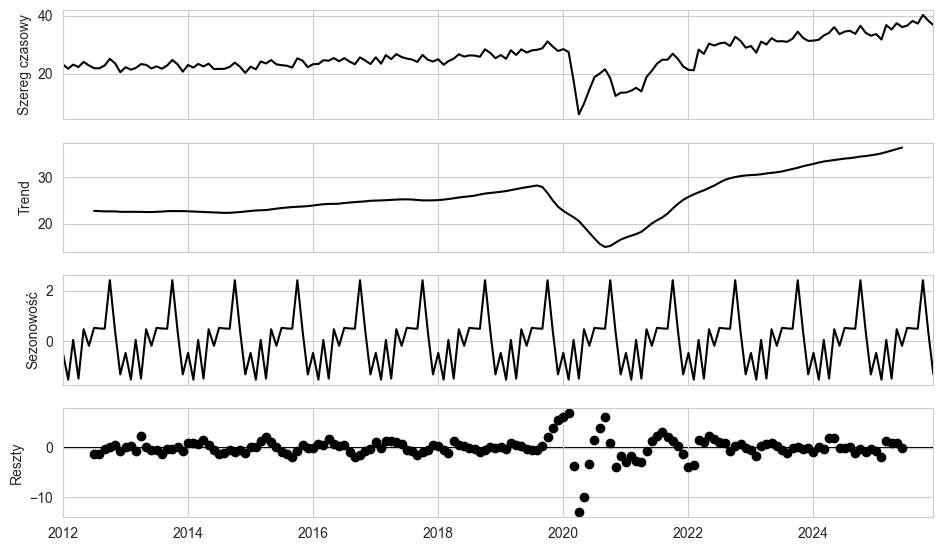

In [19]:
decomp_plot(
    monthly_data["tk_pas_liczba"],
    file="../figures/tk_pas_liczba_decomp.png",
    save_file=False
)

## Praca przewozowa

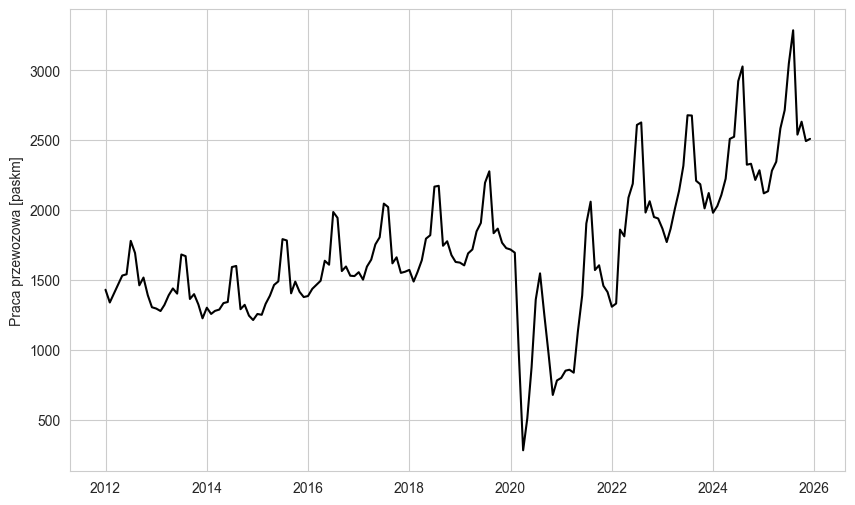

In [20]:
general_plot(
    monthly_data["tk_pas_prac_przew"],
    file="../figures/tk_pas_prac_przew.png",
    ylabel="Praca przewozowa [paskm]",
    title=None,
    save_file=False
)

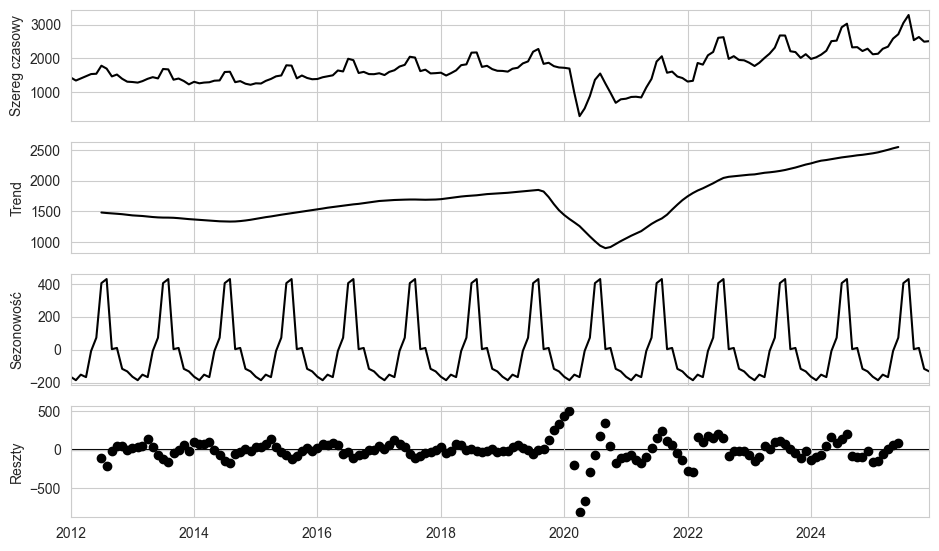

In [21]:
decomp_plot(
    monthly_data["tk_pas_prac_przew"],
    file="../figures/tk_pas_prac_przew_decomp.png",
    save_file=False
)

## Praca eksploatacyjna

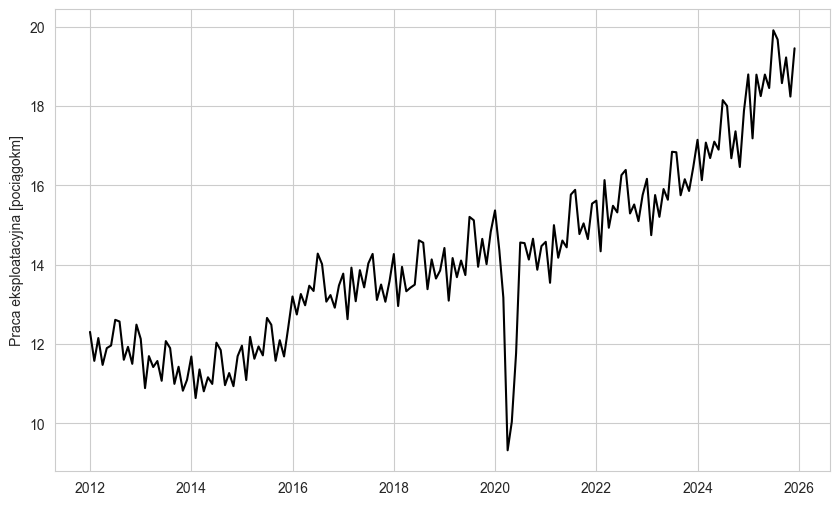

In [22]:
general_plot(
    monthly_data["tk_pas_prac_eksp"],
    file="../figures/tk_pas_prac_eksp.png",
    ylabel="Praca eksploatacyjna [pociągokm]",
    title=None,
    save_file=False
)

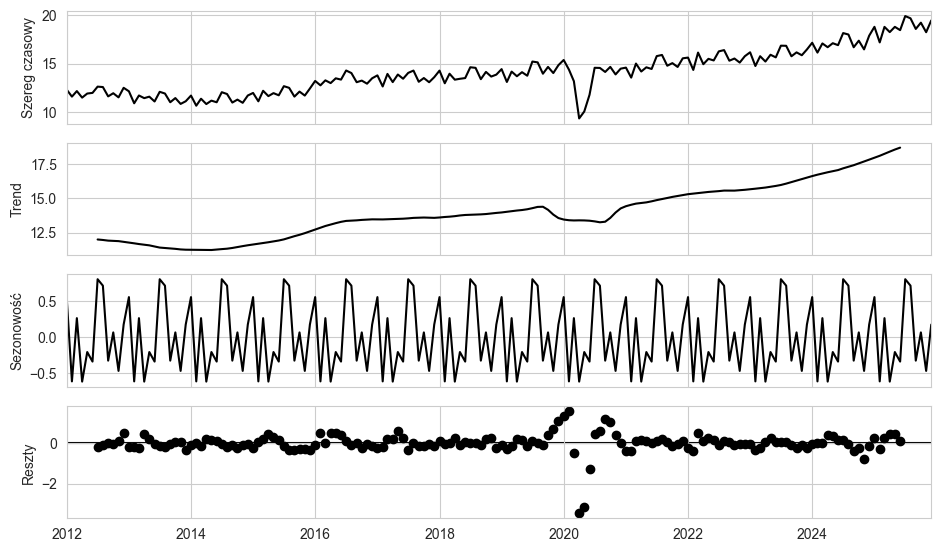

In [23]:
decomp_plot(
    monthly_data["tk_pas_prac_eksp"],
    file="../figures/tk_pas_prac_eksp_decomp.png",
    save_file=False
)

## Ładowność dynamiczna

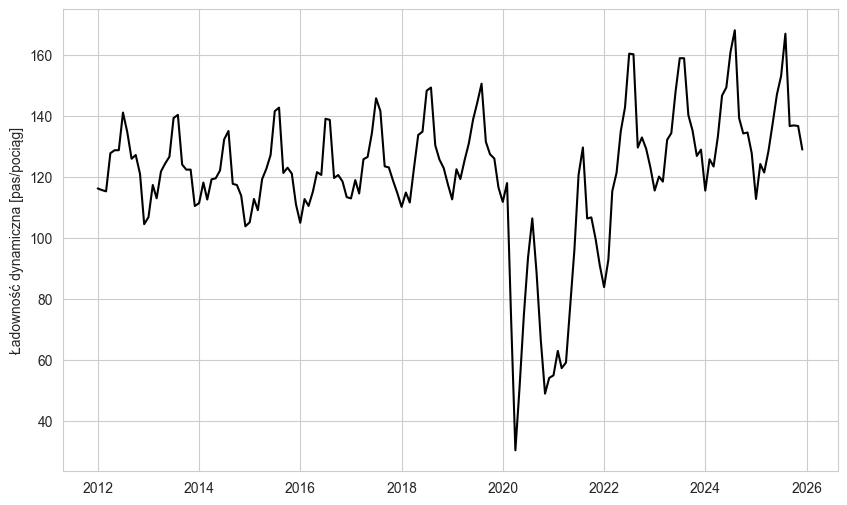

In [24]:
general_plot(
    monthly_data["tk_pas_lad_dyn"],
    file="../figures/tk_pas_lad_dyn.png",
    ylabel="Ładowność dynamiczna [pas/pociąg]",
    title=None,
    save_file=False
)

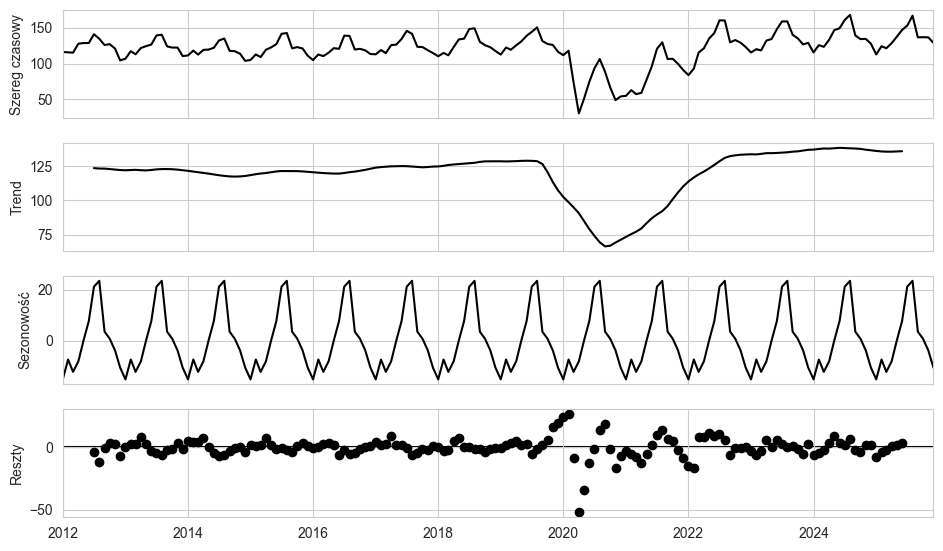

In [25]:
decomp_plot(
    monthly_data["tk_pas_lad_dyn"],
    file="../figures/tk_pas_lad_dyn_decomp.png",
    save_file=False
)

## Intensywność transportowa

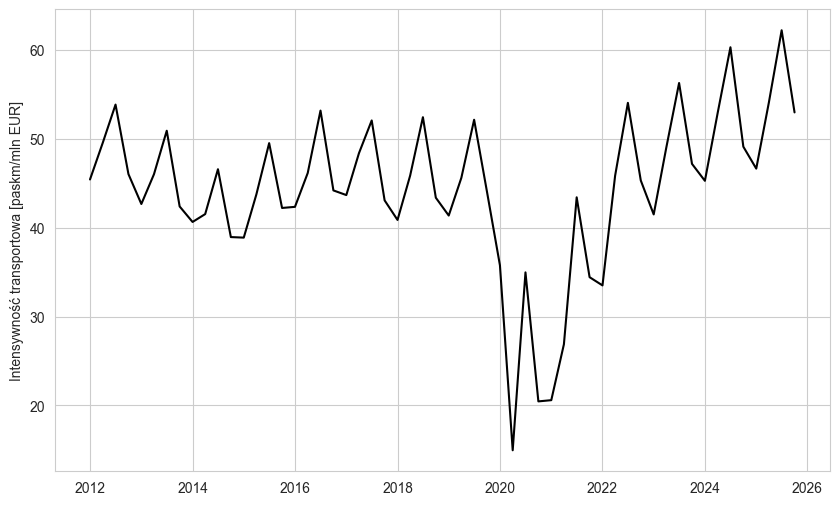

In [26]:
general_plot(
    quarterly_data["tk_pas_int_tran"],
    file="../figures/tk_pas_int_tran.png",
    ylabel="Intensywność transportowa [paskm/mln EUR]",
    title=None,
    save_file=False
)

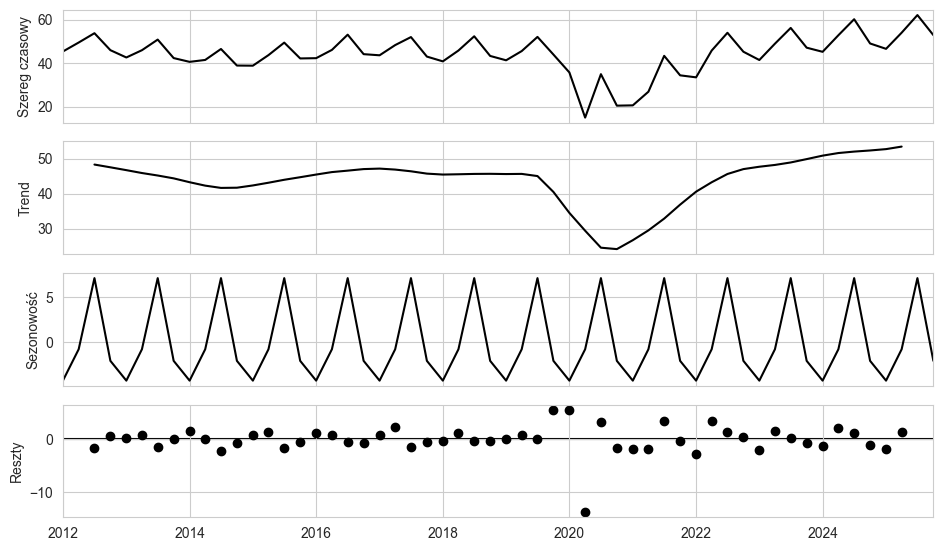

In [27]:
decomp_plot(
    quarterly_data["tk_pas_int_tran"],
    file="../figures/tk_pas_int_tran_decomp.png",
    save_file=False
)

# Transport drogowy

## Masa towarów

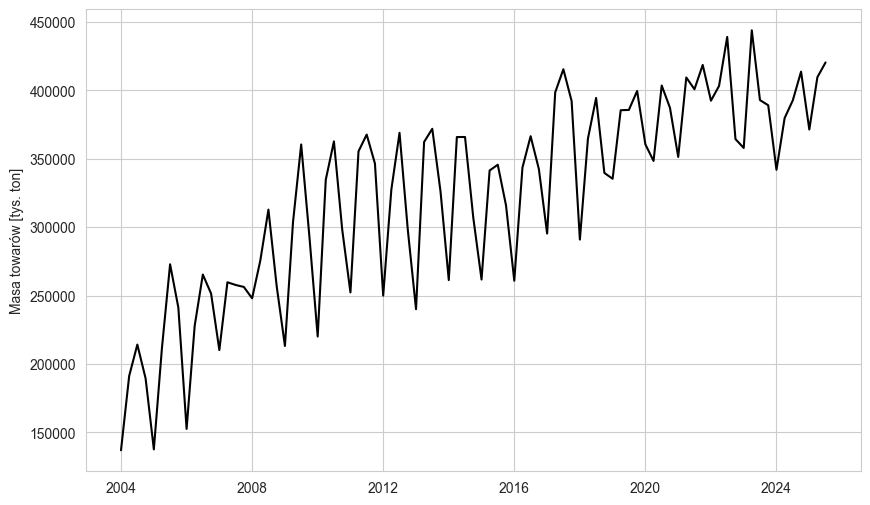

In [28]:
general_plot(
    quarterly_data["td_tow_masa"],
    file="../figures/td_tow_masa.png",
    ylabel="Masa towarów [tys. ton]",
    title=None,
    save_file=False
)

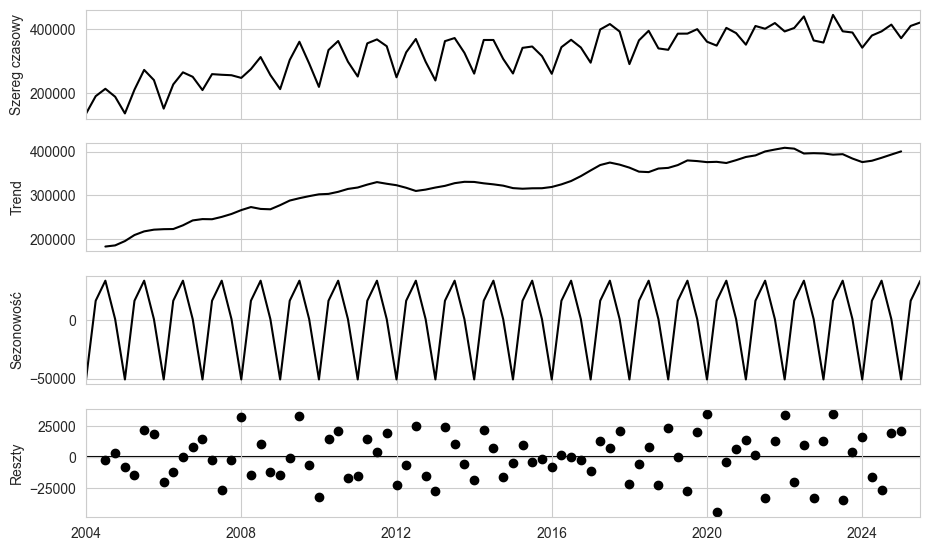

In [29]:
decomp_plot(
    quarterly_data["td_tow_masa"],
    file="../figures/td_tow_masa_decomp.png",
    save_file=False
)

## Praca przewozowa

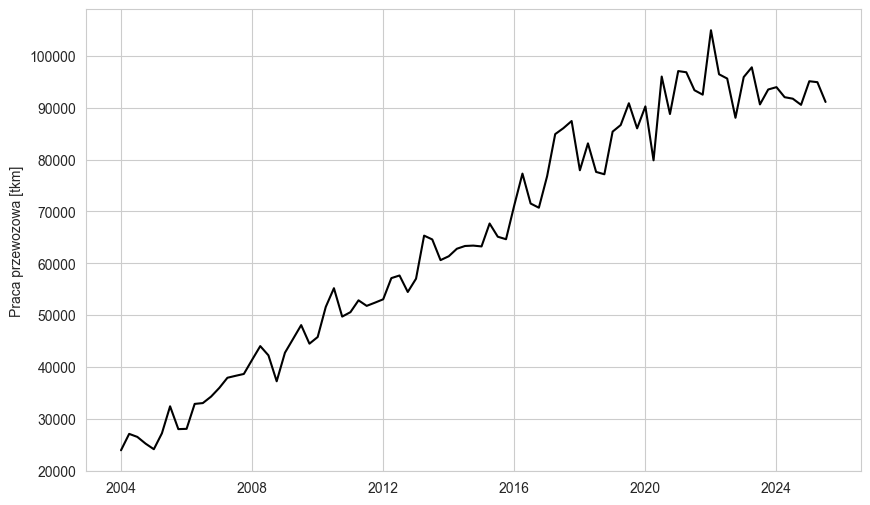

In [30]:
general_plot(
    quarterly_data["td_tow_prac_przew"],
    file="../figures/td_tow_prac_przew.png",
    ylabel="Praca przewozowa [tkm]",
    title=None,
    save_file=False
)

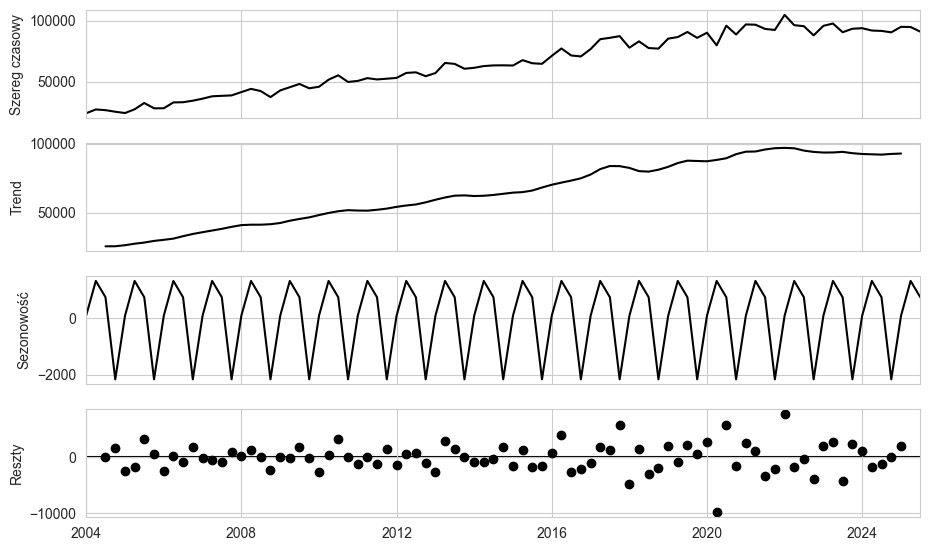

In [31]:
decomp_plot(
    quarterly_data["td_tow_prac_przew"],
    file="../figures/td_tow_prac_przew_decomp.png",
    save_file=False
)

## Praca eksploatacyjna

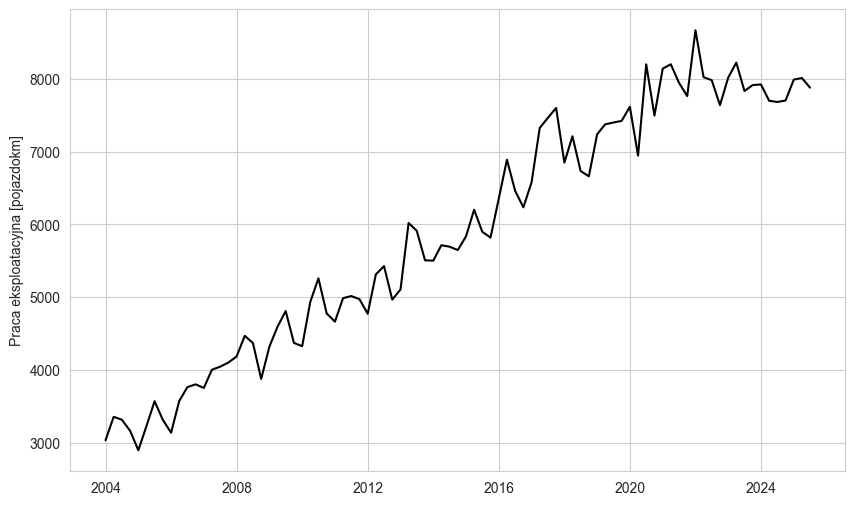

In [32]:
general_plot(
    quarterly_data["td_tow_prac_eksp"],
    file="../figures/td_tow_prac_eksp.png",
    ylabel="Praca eksploatacyjna [pojazdokm]",
    title=None,
    save_file=False
)

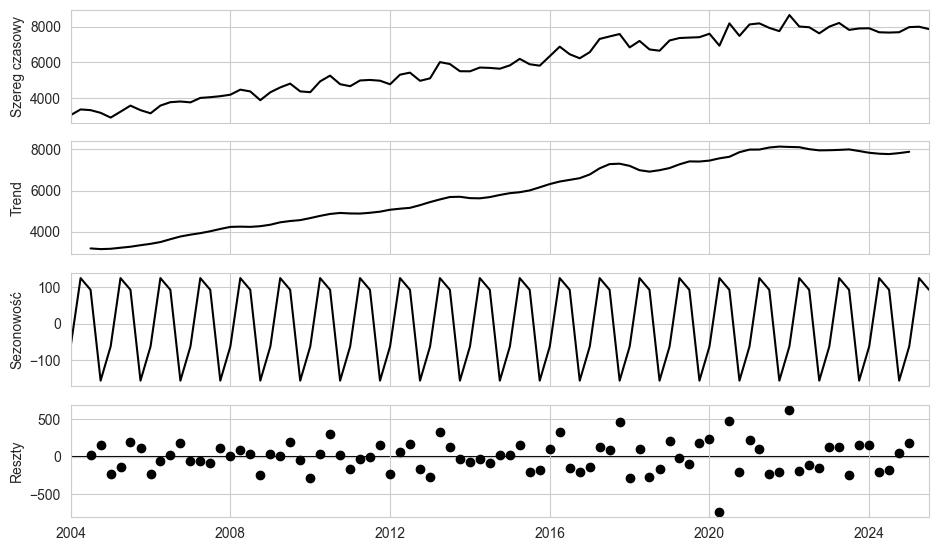

In [33]:
decomp_plot(
    quarterly_data["td_tow_prac_eksp"],
    file="../figures/td_tow_prac_eksp_decomp.png",
    save_file=False
)

## Ładowność dynamiczna

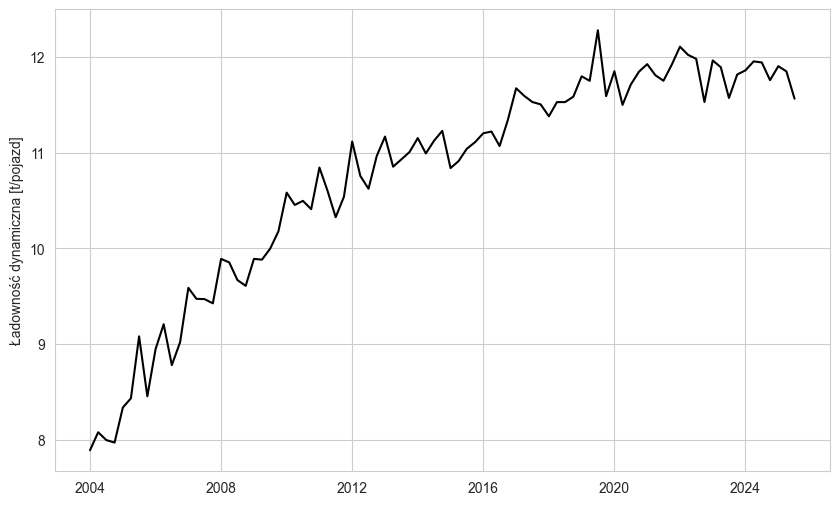

In [34]:
general_plot(
    quarterly_data["td_tow_lad_dyn"],
    file="../figures/td_tow_lad_dyn.png",
    ylabel="Ładowność dynamiczna [t/pojazd]",
    title=None,
    save_file=False
)

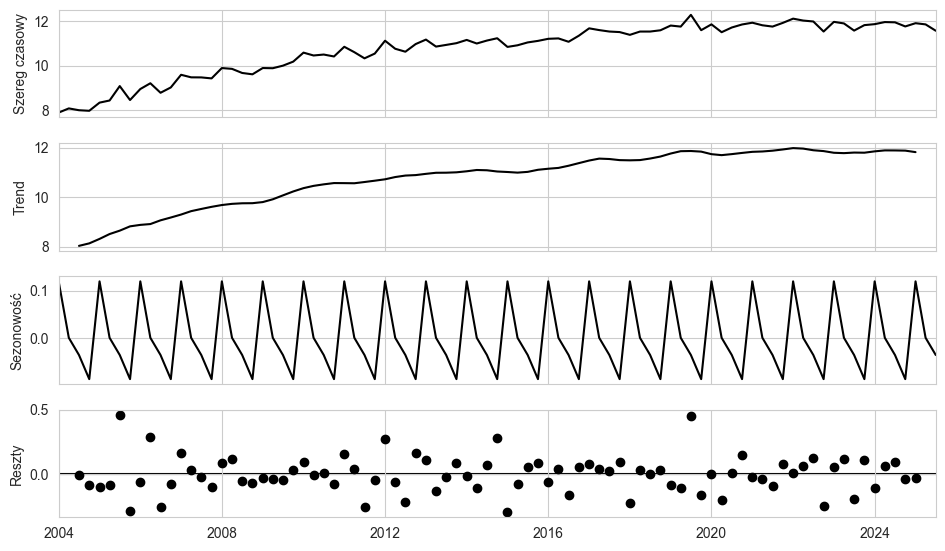

In [35]:
decomp_plot(
    quarterly_data["td_tow_lad_dyn"],
    file="../figures/td_tow_lad_dyn_decomp.png",
    save_file=False
)

## Masa jednostkowa

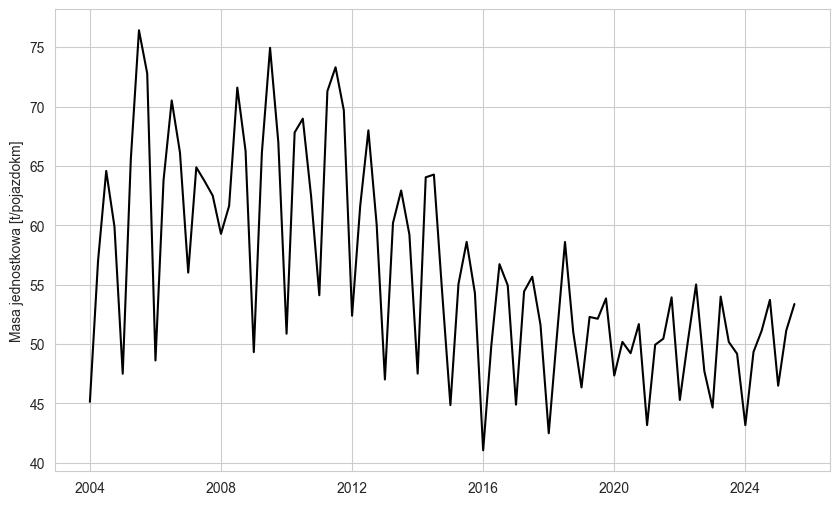

In [36]:
general_plot(
    quarterly_data["td_tow_masa_jedn"],
    file="../figures/td_tow_masa_jedn.png",
    ylabel="Masa jednostkowa [t/pojazdokm]",
    title=None,
    save_file=False
)

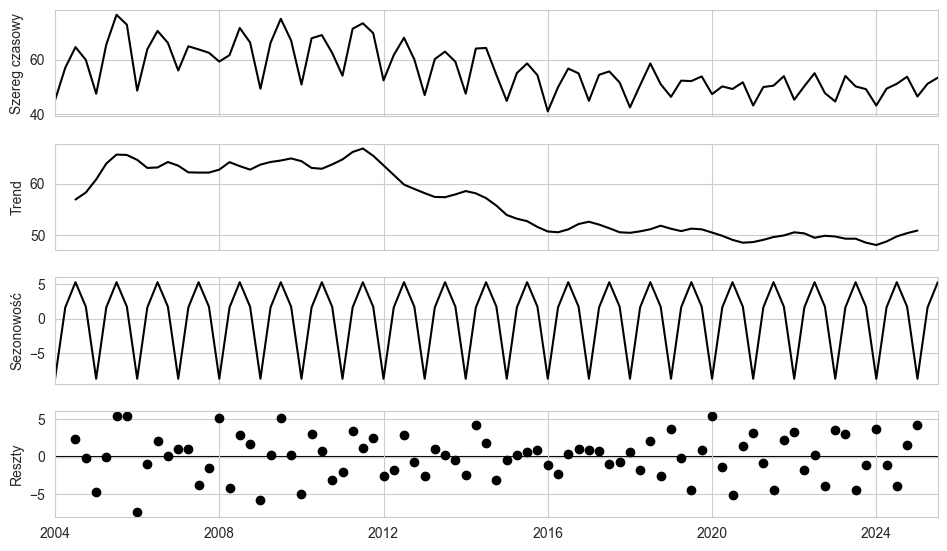

In [37]:
decomp_plot(
    quarterly_data["td_tow_masa_jedn"],
    file="../figures/td_tow_masa_jedn_decomp.png",
    save_file=False
)

## Intensywność transportowa

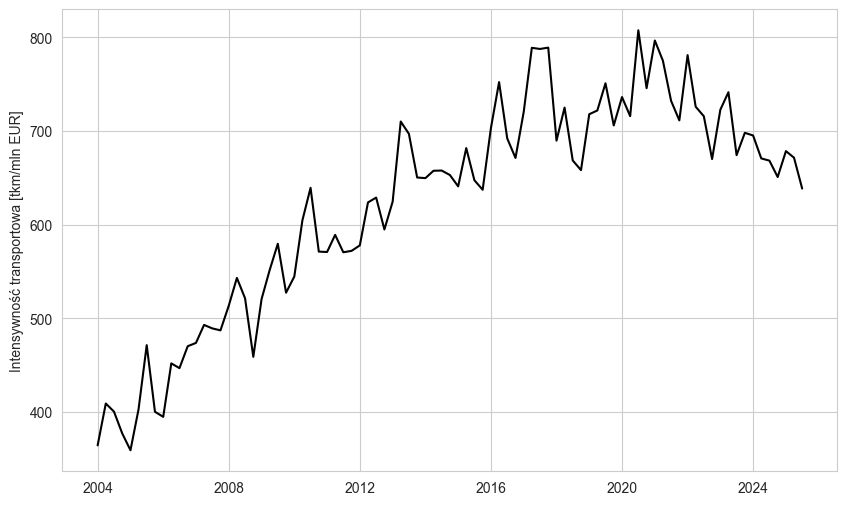

In [38]:
general_plot(
    quarterly_data["td_tow_int_tran"],
    file="../figures/td_tow_int_tran.png",
    ylabel="Intensywność transportowa [tkm/mln EUR]",
    title=None,
    save_file=False
)

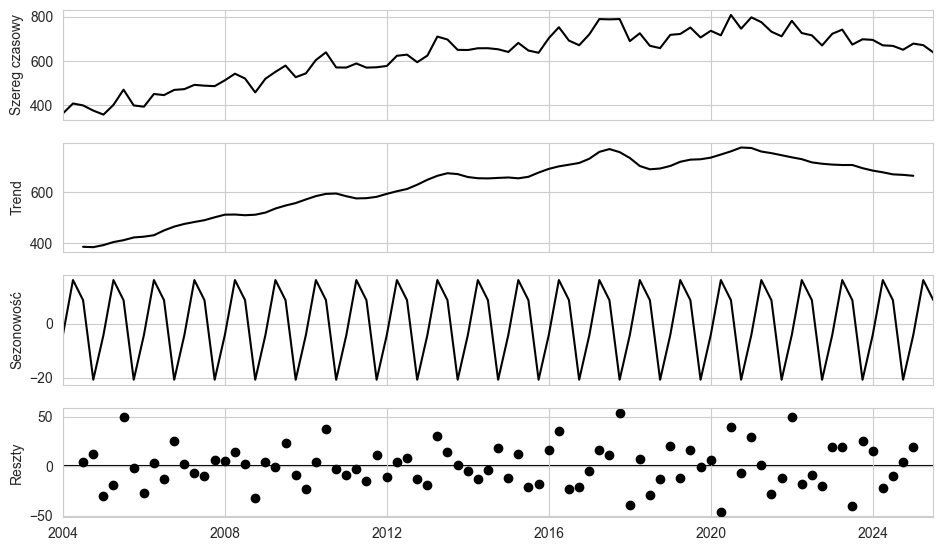

In [39]:
decomp_plot(
    quarterly_data["td_tow_int_tran"],
    file="../figures/td_tow_int_tran_decomp.png",
    save_file=False
)

## Samochody osobowe

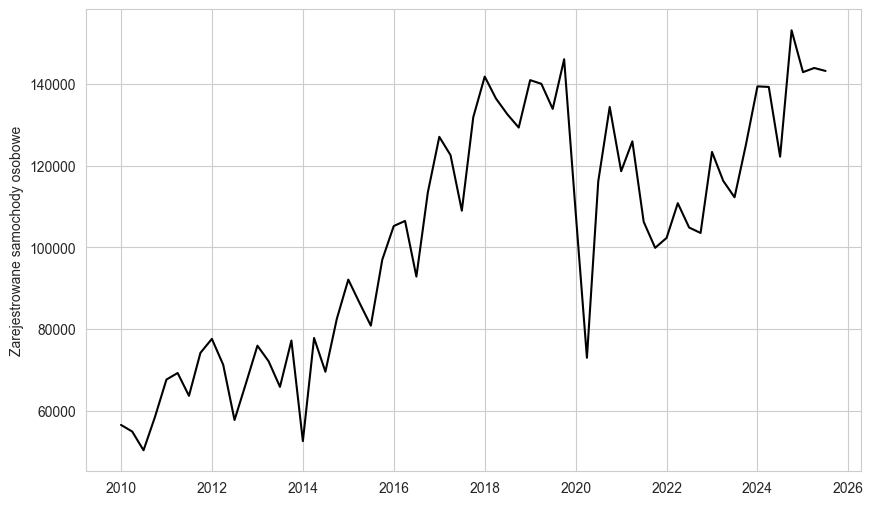

In [40]:
general_plot(
    quarterly_data["td_poj_sam_os"],
    file="../figures/td_poj_sam_os.png",
    ylabel="Zarejestrowane samochody osobowe",
    title=None,
    save_file=False
)

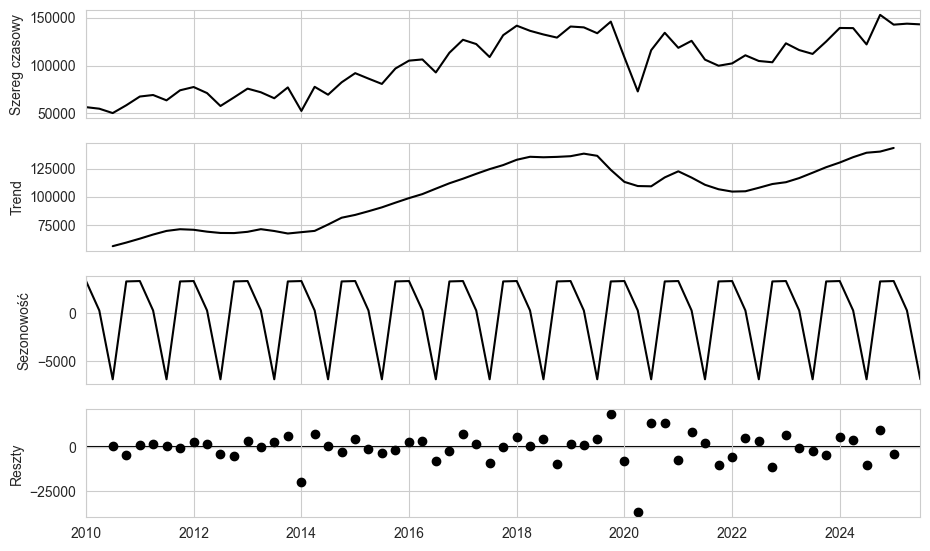

In [41]:
decomp_plot(
    quarterly_data["td_poj_sam_os"],
    file="../figures/td_poj_sam_os_decomp.png",
    save_file=False
)

## Samochody ciężarowe

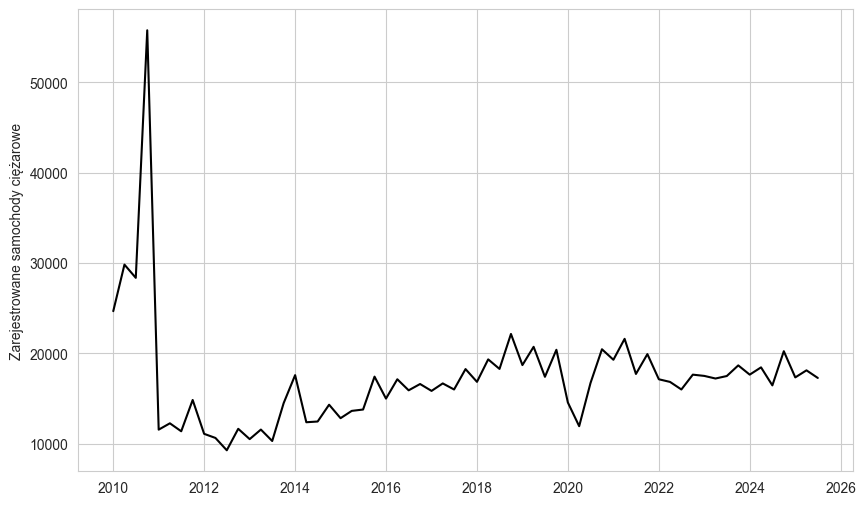

In [42]:
general_plot(
    quarterly_data["td_poj_sam_ciez"],
    file="../figures/td_poj_sam_ciez.png",
    ylabel="Zarejestrowane samochody ciężarowe",
    title=None,
    save_file=False
)

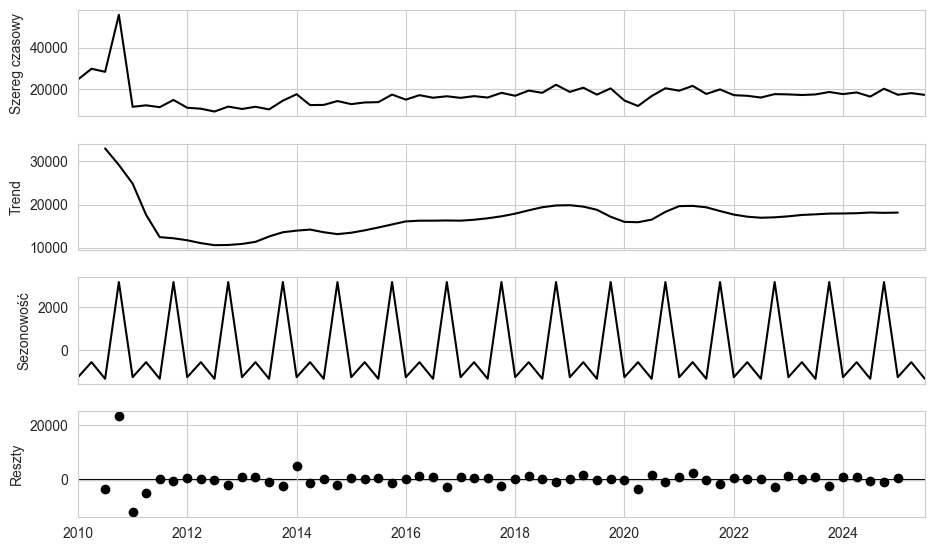

In [43]:
decomp_plot(
    quarterly_data["td_poj_sam_ciez"],
    file="../figures/td_poj_sam_ciez_decomp.png",
    save_file=False
)

## Ciągniki siodłowe

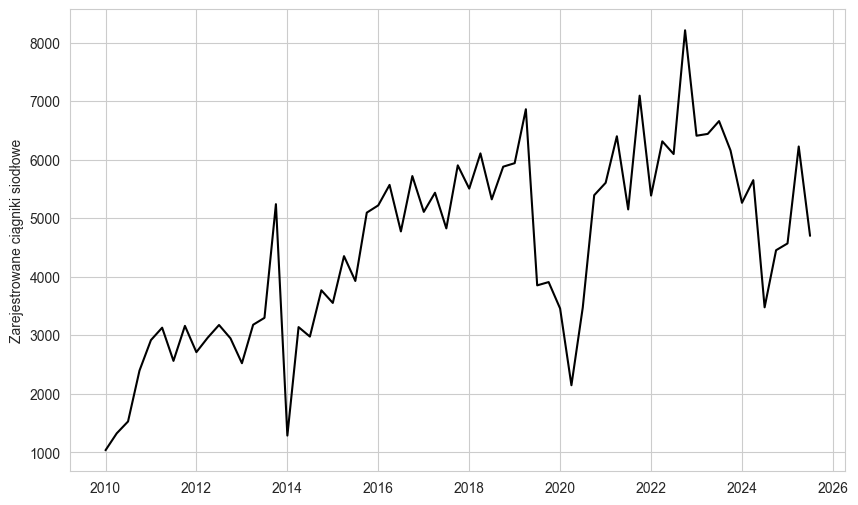

In [44]:
general_plot(
    quarterly_data["td_poj_ciag_siod"],
    file="../figures/td_poj_ciag_siod.png",
    ylabel="Zarejestrowane ciągniki siodłowe",
    title=None,
    save_file=False
)

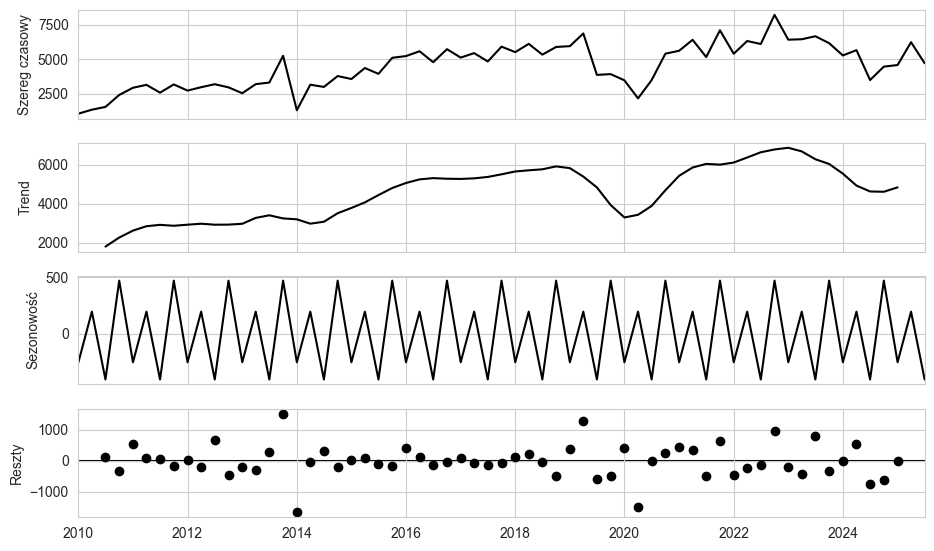

In [45]:
decomp_plot(
    quarterly_data["td_poj_ciag_siod"],
    file="../figures/td_poj_ciag_siod_decomp.png",
    save_file=False
)

## Autobusy i trolejbusy

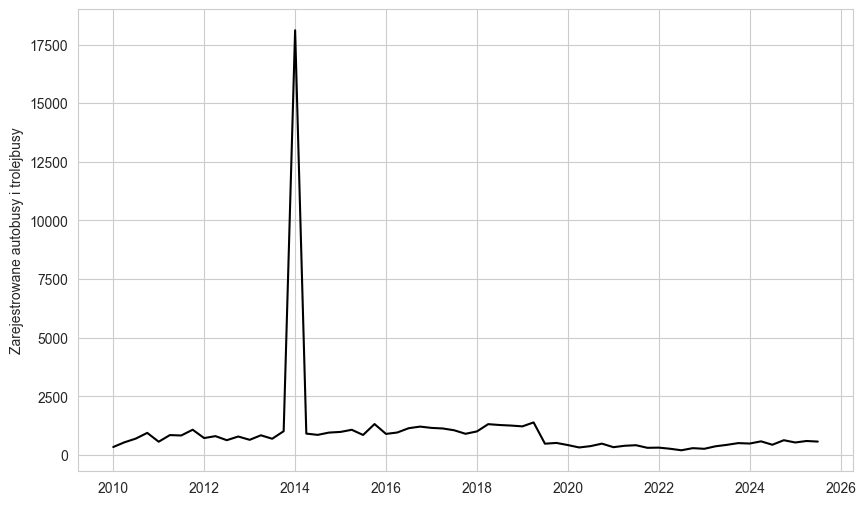

In [46]:
general_plot(
    quarterly_data["td_poj_ait"],
    file="../figures/td_poj_ait.png",
    ylabel="Zarejestrowane autobusy i trolejbusy",
    title=None,
    save_file=False
)

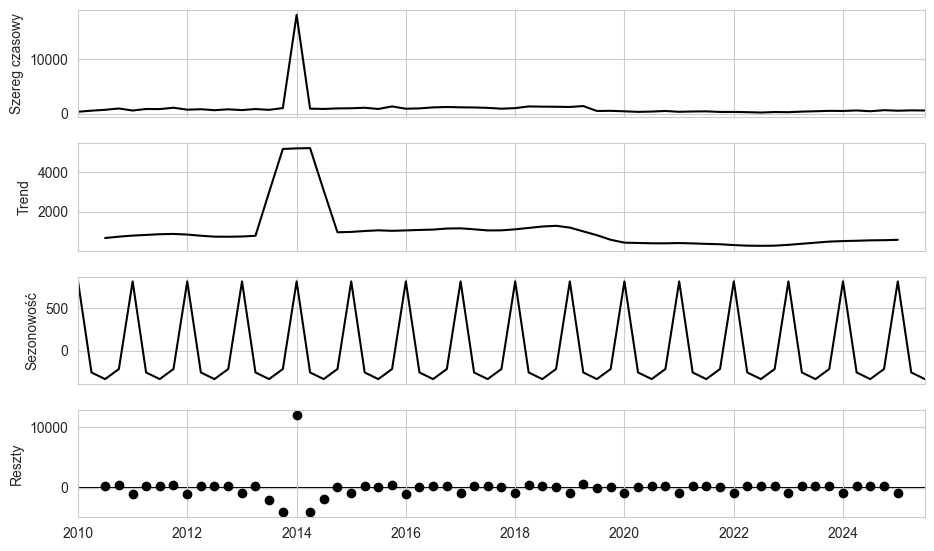

In [47]:
decomp_plot(
    quarterly_data["td_poj_ait"],
    file="../figures/td_poj_ait_decomp.png",
    save_file=False
)

# Infrastruktura kolejowa

## Linie kolejowe eksploatowane

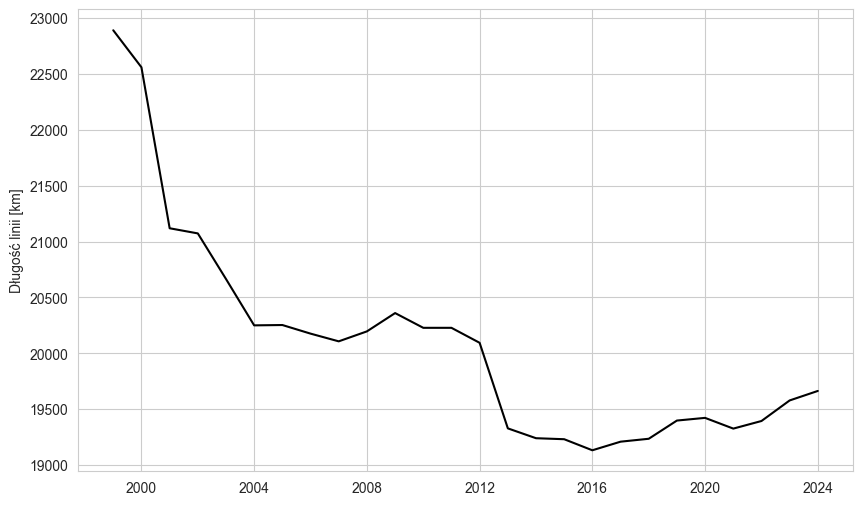

In [48]:
general_plot(
    yearly_data["ink_lin_eksp"],
    file="../figures/ink_lin_eksp.png",
    ylabel="Długość linii [km]",
    title=None,
    save_file=False
)

## Linie kolejowe zelektryfikowane dwu- i więcej torowe

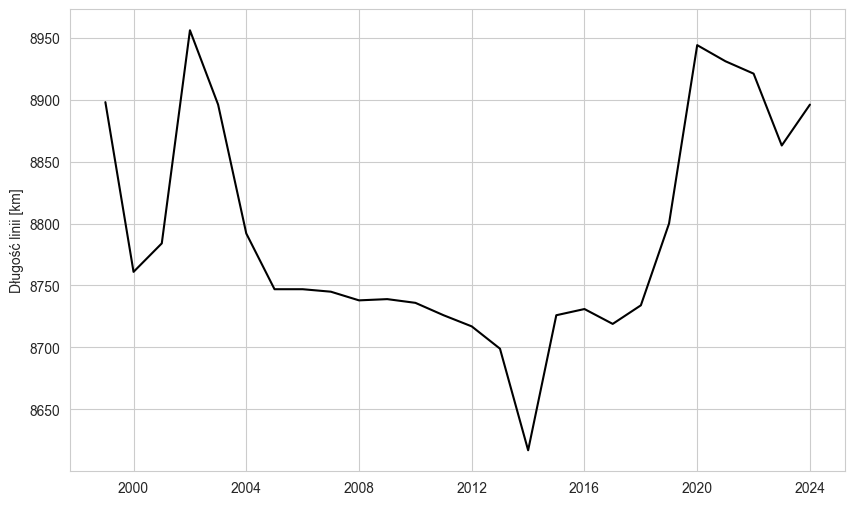

In [49]:
general_plot(
    yearly_data["ink_lin_dwu_el"],
    file="../figures/ink_lin_dwu_el.png",
    ylabel="Długość linii [km]",
    title=None,
    save_file=False
)

## Udział linii zelektryfikowanych dwu- i więcej torowych

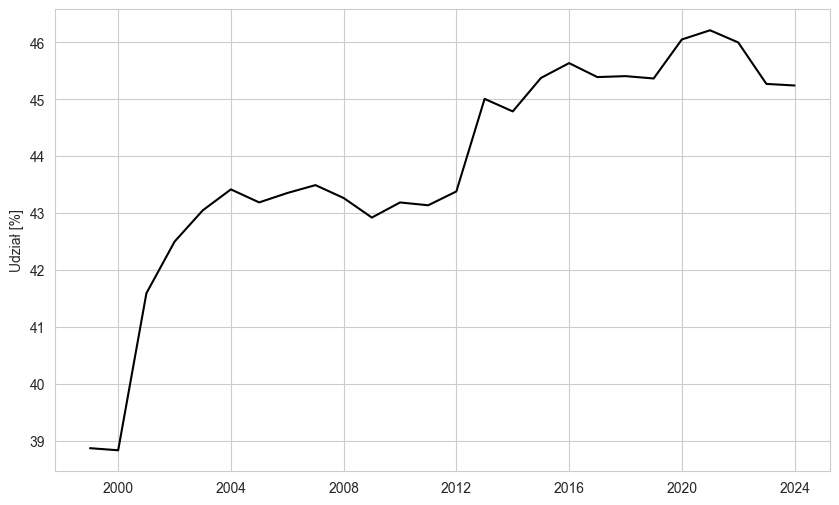

In [50]:
general_plot(
    yearly_data["ink_lin_dwu_el_udzial"],
    file="../figures/ink_lin_dwu_el_udzial.png",
    ylabel="Udział [%]",
    title=None,
    save_file=False
)

## Wydatki na utrzymanie

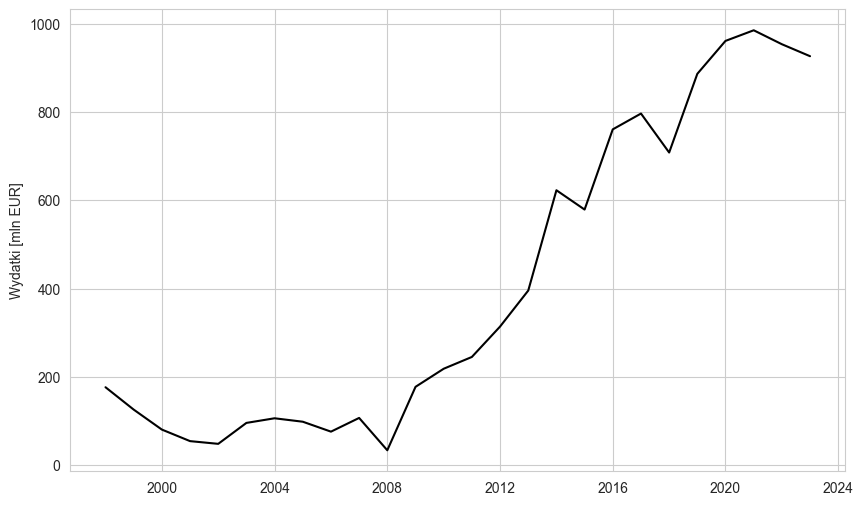

In [51]:
general_plot(
    yearly_data["ink_wyd_ut"].div(1e6),
    file="../figures/ink_wyd_ut.png",
    ylabel="Wydatki [mln EUR]",
    title=None,
    save_file=False
)

## Wydatki inwestycyjne

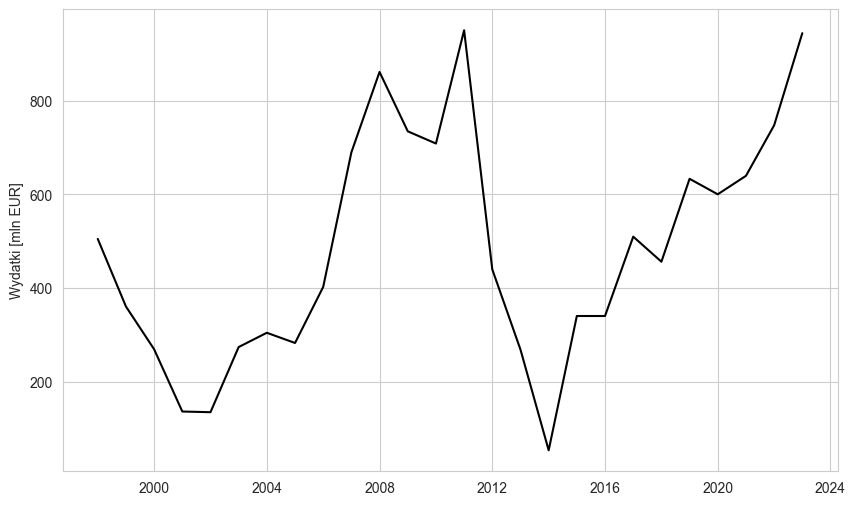

In [52]:
general_plot(
    yearly_data["ink_wyd_inw"].div(1e6),
    file="../figures/ink_wyd_inw.png",
    ylabel="Wydatki [mln EUR]",
    title=None,
    save_file=False
)

## Udziały wydatków

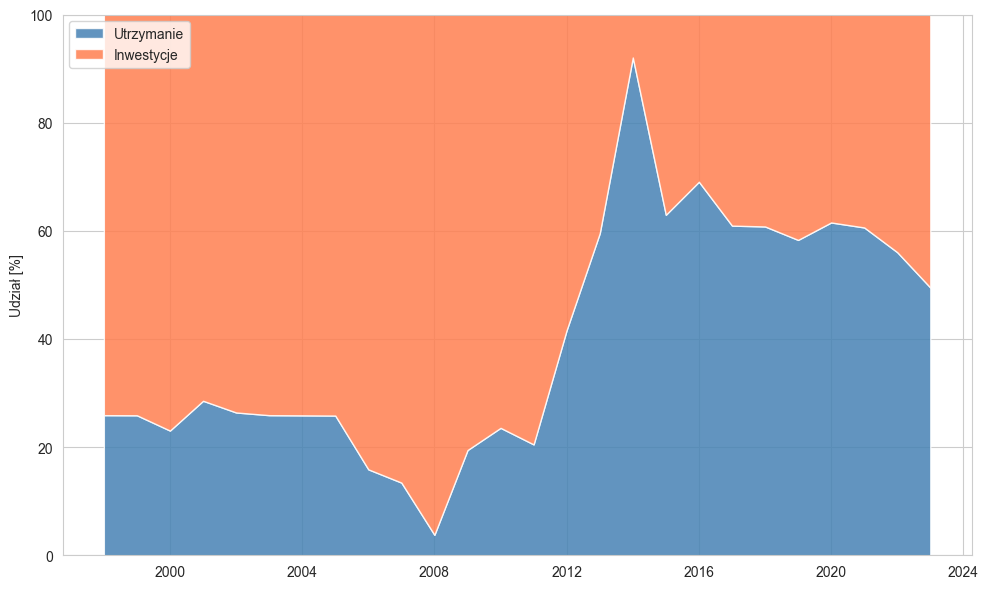

In [53]:
structure_plot(
    yearly_data.index,
    yearly_data["ink_wyd_ut_udzial"],
    yearly_data["ink_wyd_inw_udzial"],
    labels=["Utrzymanie", "Inwestycje"],
    colors=['steelblue', 'coral'],
    file="../figures/ink_wyd_udzialy.png",
    save_file=True,
    title=None,
    ylabel="Udział [%]"
)

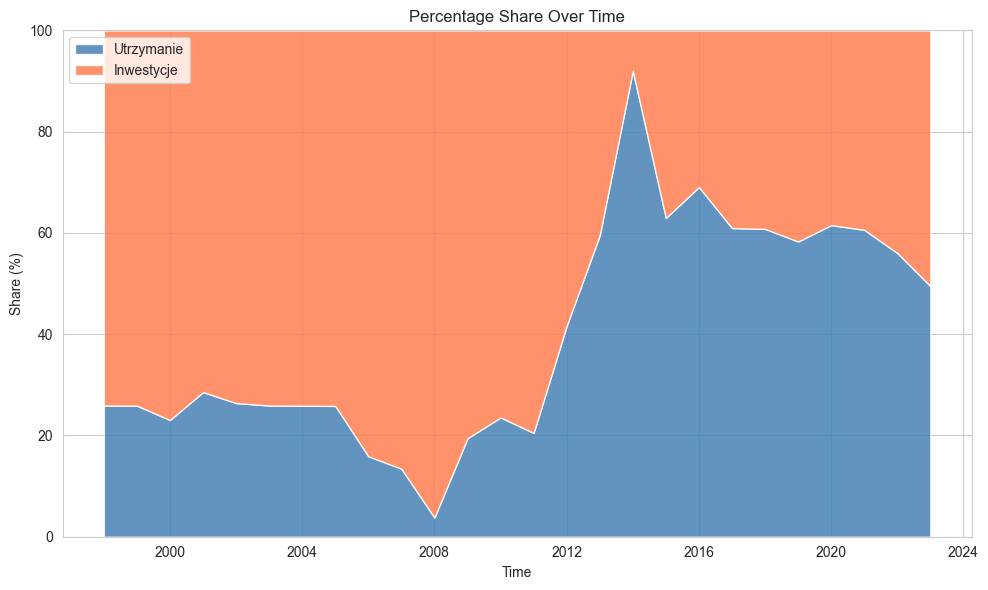

In [54]:
fig, ax = plt.subplots(figsize=PLOT_SIZE)

ax.stackplot(yearly_data.index, yearly_data["ink_wyd_ut_udzial"], yearly_data["ink_wyd_inw_udzial"],
             labels=["Utrzymanie", "Inwestycje"],
             colors=['steelblue', 'coral'],
             alpha=0.85)

ax.set_ylim(0, 100)
ax.set_ylabel('Share (%)')
ax.set_xlabel('Time')
ax.set_title('Percentage Share Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Infrastruktura drogowa

## Drogi ekspresowe

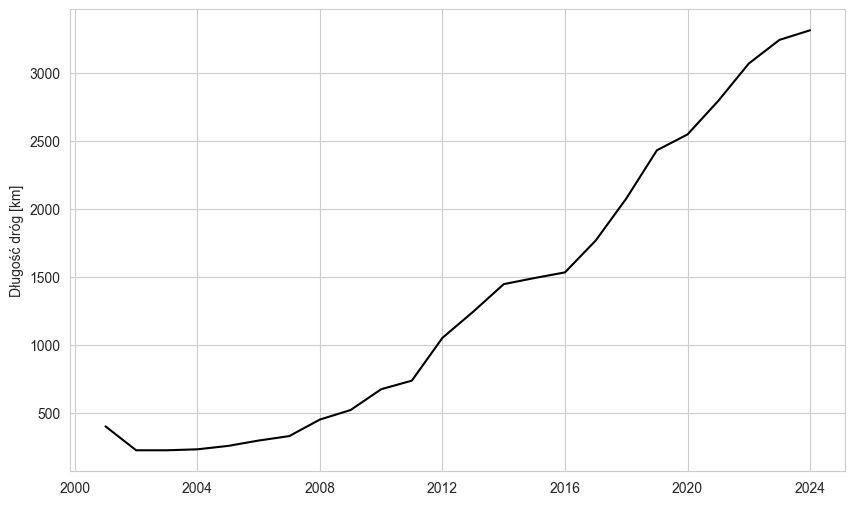

In [55]:
general_plot(
    yearly_data["ind_drog_ekspr"],
    file="../figures/ind_drog_ekspr.png",
    ylabel="Długość dróg [km]",
    title=None,
    save_file=False
)

## Autostrady

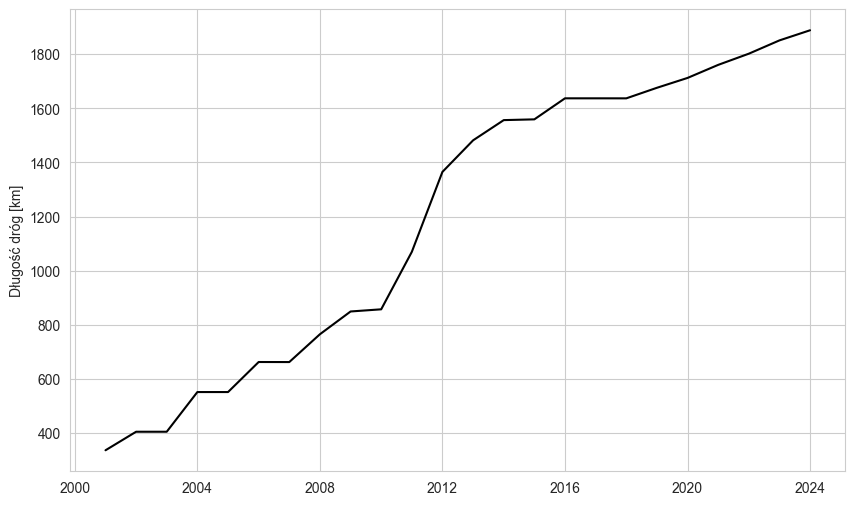

In [56]:
general_plot(
    yearly_data["ind_autostrady"],
    file="../figures/ind_autostrady.png",
    ylabel="Długość dróg [km]",
    title=None,
    save_file=False
)

## Drogi publiczne

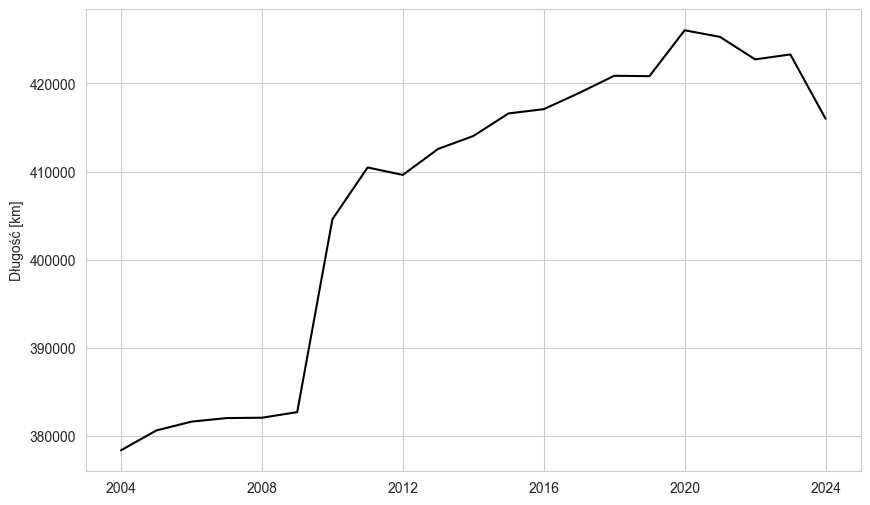

In [57]:
general_plot(
    yearly_data["ind_pub_bez_aut_de"],
    file="../figures/ind_pub_bez_aut_de.png",
    ylabel="Długość [km]",
    title=None,
    save_file=False
)

## Wydatki na utrzymanie

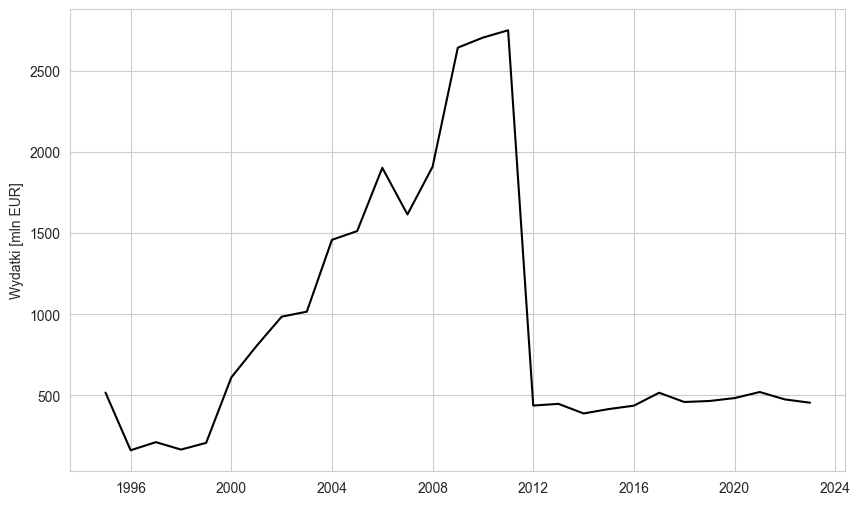

In [58]:
general_plot(
    yearly_data["ind_wyd_ut"].div(1e6),
    file="../figures/ind_wyd_ut.png",
    ylabel="Wydatki [mln EUR]",
    title=None,
    save_file=False
)

## Wydatki inwestycyjne

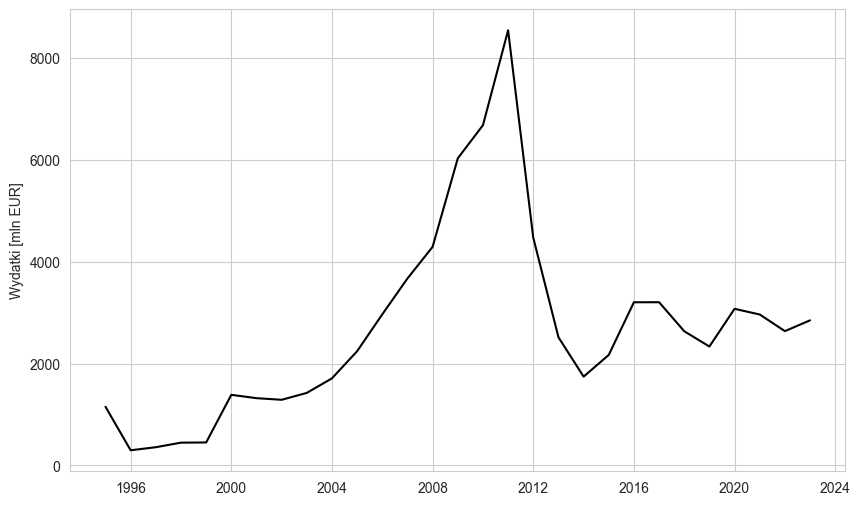

In [59]:
general_plot(
    yearly_data["ind_wyd_inw"].div(1e6),
    file="../figures/ind_wyd_inw.png",
    ylabel="Wydatki [mln EUR]",
    title=None,
    save_file=False
)

## Struktura wydatków

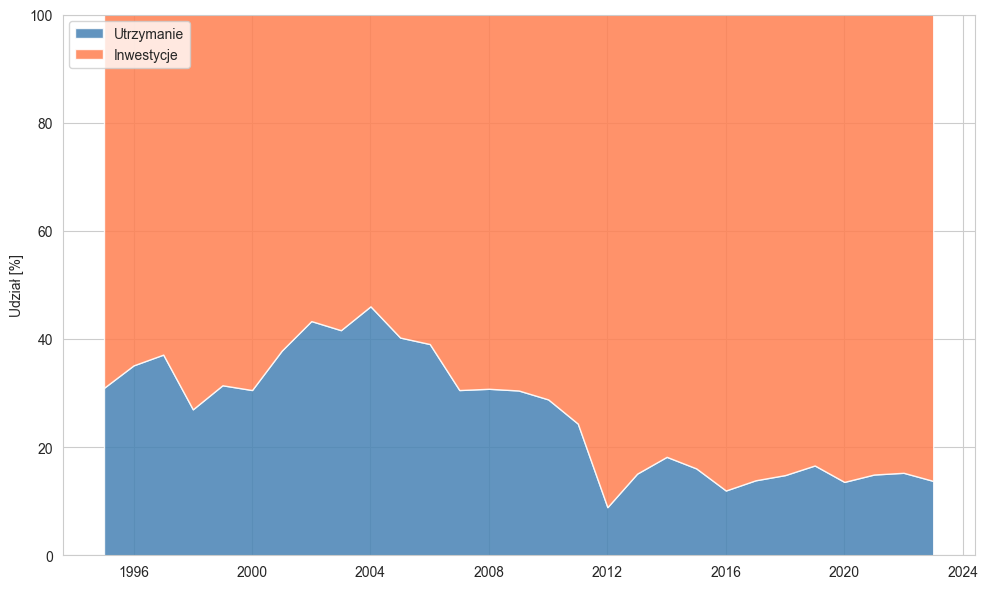

In [60]:
structure_plot(
    yearly_data.index,
    yearly_data["ind_wyd_ut_udzial"],
    yearly_data["ind_wyd_inw_udzial"],
    labels=["Utrzymanie", "Inwestycje"],
    colors=['steelblue', 'coral'],
    file="../figures/ind_wyd_udzialy.png",
    save_file=True,
    title=None,
    ylabel="Udział [%]"
)

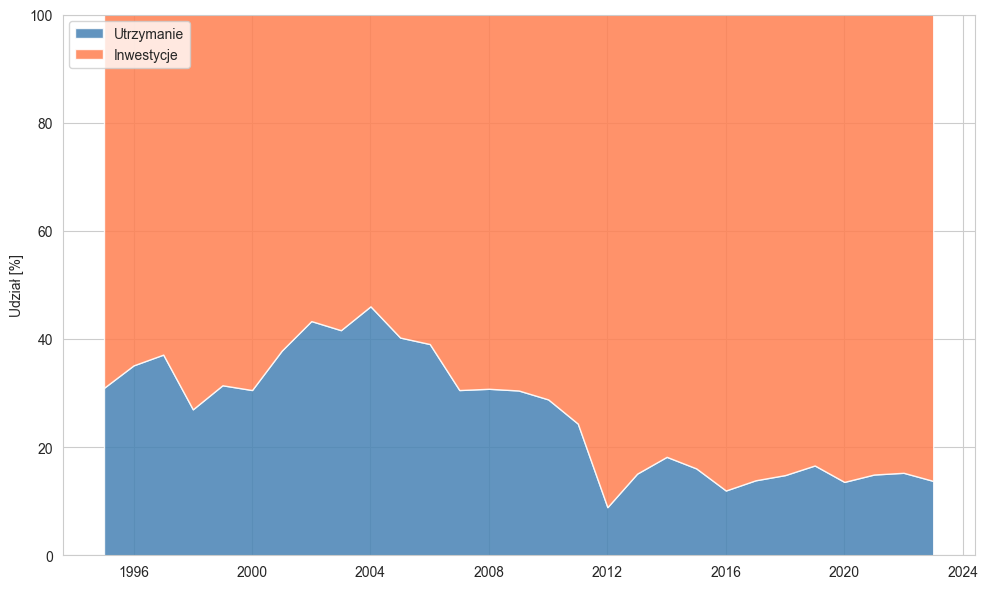

In [61]:
fig, ax = plt.subplots(figsize=PLOT_SIZE)

ax.stackplot(yearly_data.index, yearly_data["ind_wyd_ut_udzial"], yearly_data["ind_wyd_inw_udzial"], 
             labels=["Utrzymanie", "Inwestycje"],
             colors=['steelblue', 'coral'],
             alpha=0.85)

ax.set_ylim(0, 100)
ax.set_ylabel('Udział [%]')
#ax.set_xlabel('Time')
#ax.set_title('Percentage Share Over Time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Wpływ na środowisko

## Emisje w transporcie kolejowym

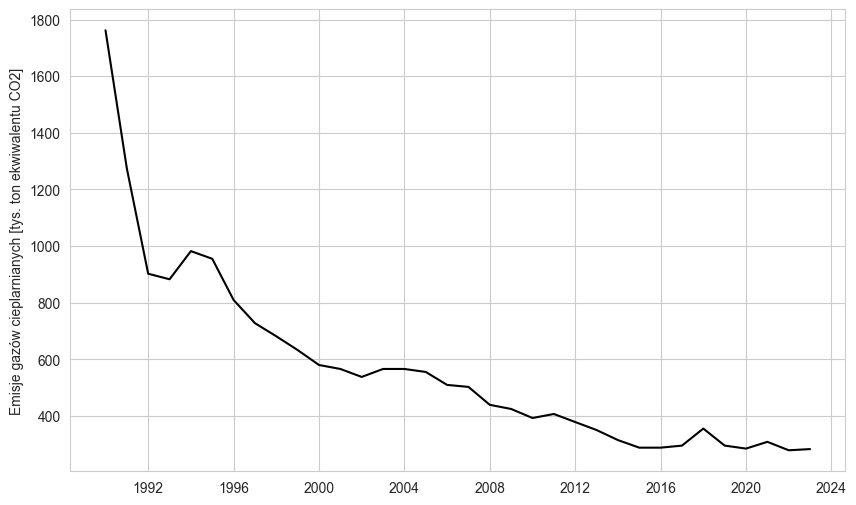

In [62]:
general_plot(
    yearly_data["env_emis_tk"],
    file="../figures/env_emis_tk.png",
    ylabel="Emisje gazów cieplarnianych [tys. ton ekwiwalentu CO2]",
    title=None,
    save_file=False
)

## Emisje w transporcie drogowym

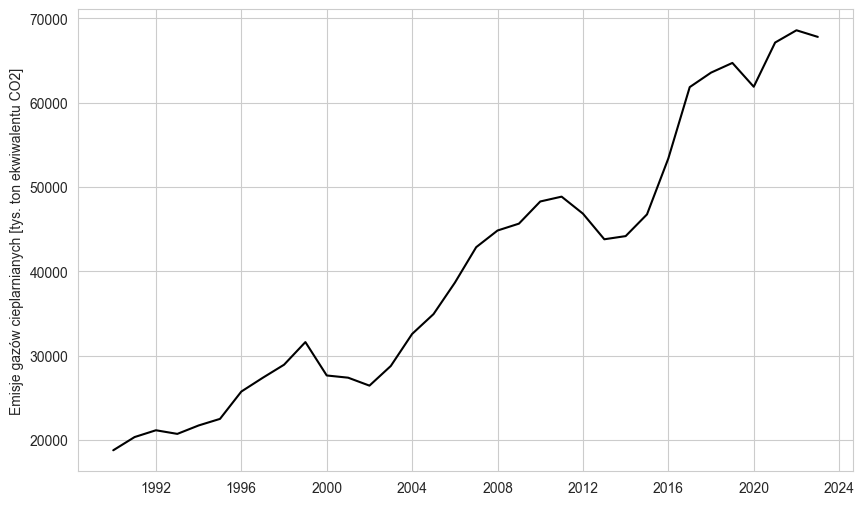

In [63]:
general_plot(
    yearly_data["env_emis_td"],
    file="../figures/env_emis_td.png",
    ylabel="Emisje gazów cieplarnianych [tys. ton ekwiwalentu CO2]",
    title=None,
    save_file=False
)

## Struktura emisji

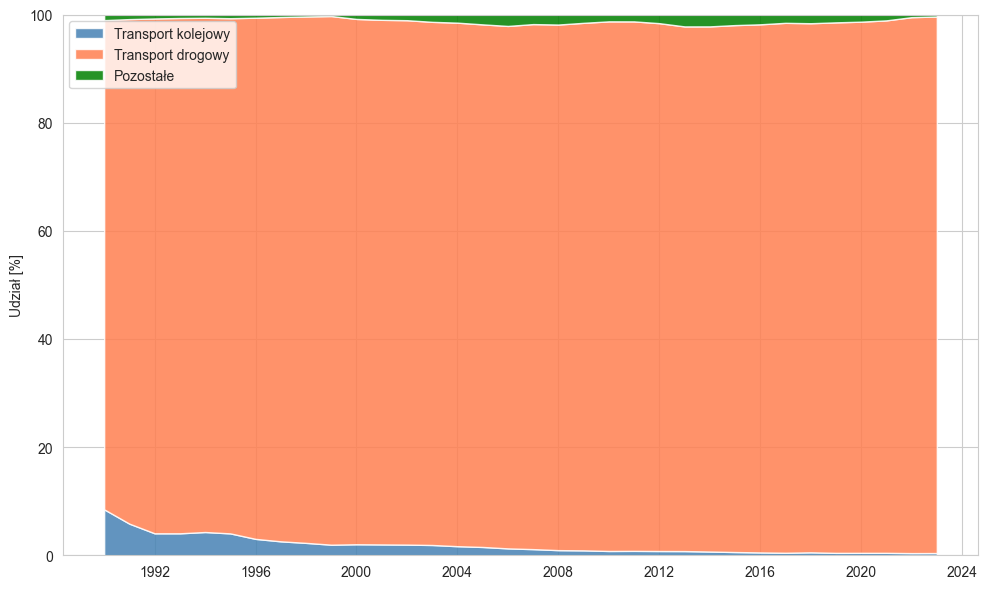

In [64]:
structure_plot(
    yearly_data.index,
    yearly_data["env_emis_tk_udzial"],
    yearly_data["env_emis_td_udzial"],
    yearly_data["env_emis_poz_udzial"],
    labels=["Transport kolejowy", "Transport drogowy", "Pozostałe"],
    colors=["steelblue", "coral", "green"],
    file="../figures/env_emis_struktura.png",
    save_file=True,
    title=None,
    ylabel="Udział [%]"
)

## Emisje w transporcie kolejowym na masę towarów

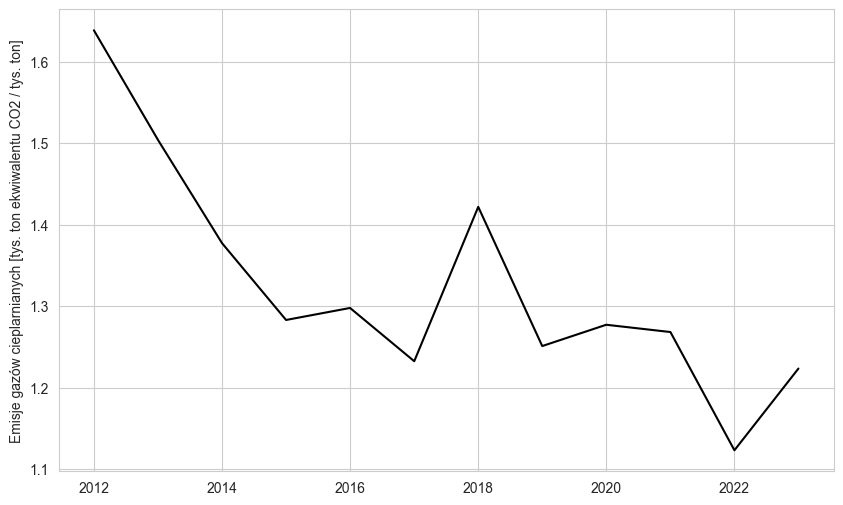

In [65]:
general_plot(
    yearly_data["env_emis_tk_masa"],
    file="../figures/env_emis_tk_masa.png",
    ylabel="Emisje gazów cieplarnianych [tys. ton ekwiwalentu CO2 / tys. ton]",
    title=None,
    save_file=False
)

## Emisje w transporcie drogowym na masę towarów

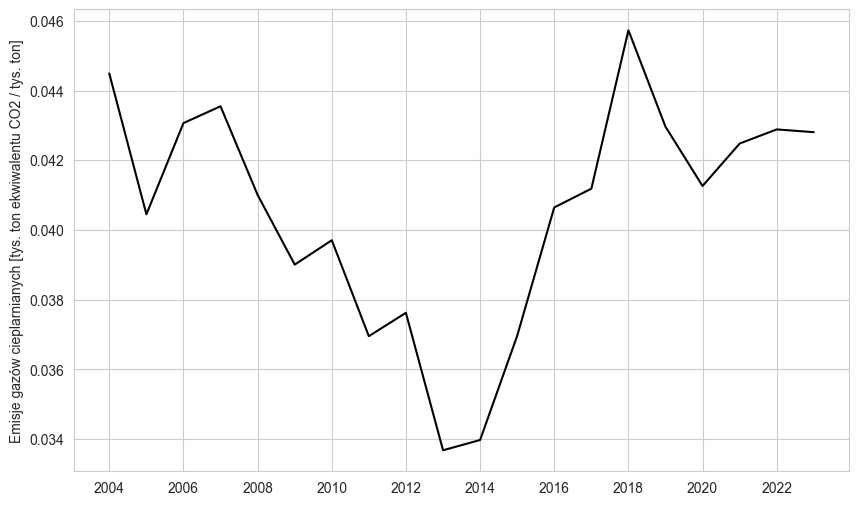

In [66]:
general_plot(
    yearly_data["env_emis_td_masa"],
    file="../figures/env_emis_td_masa.png",
    ylabel="Emisje gazów cieplarnianych [tys. ton ekwiwalentu CO2 / tys. ton]",
    title=None,
    save_file=False
)

## Emisje w transporcie kolejowym na pracę przewozową

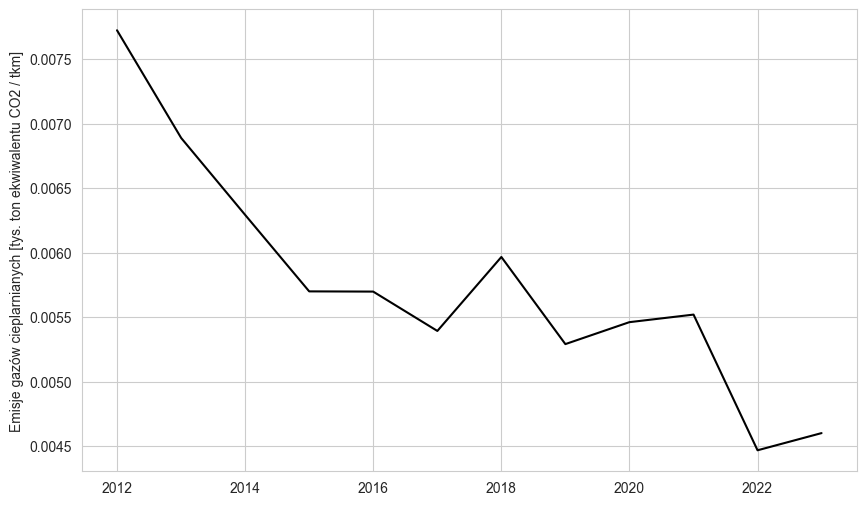

In [67]:
general_plot(
    yearly_data["env_emis_tk_prac_przew"],
    file="../figures/env_emis_tk_prac_przew.png",
    ylabel="Emisje gazów cieplarnianych [tys. ton ekwiwalentu CO2 / tkm]",
    title=None,
    save_file=True
)

## Emisje w tranporcie drogowym na pracę przewozową

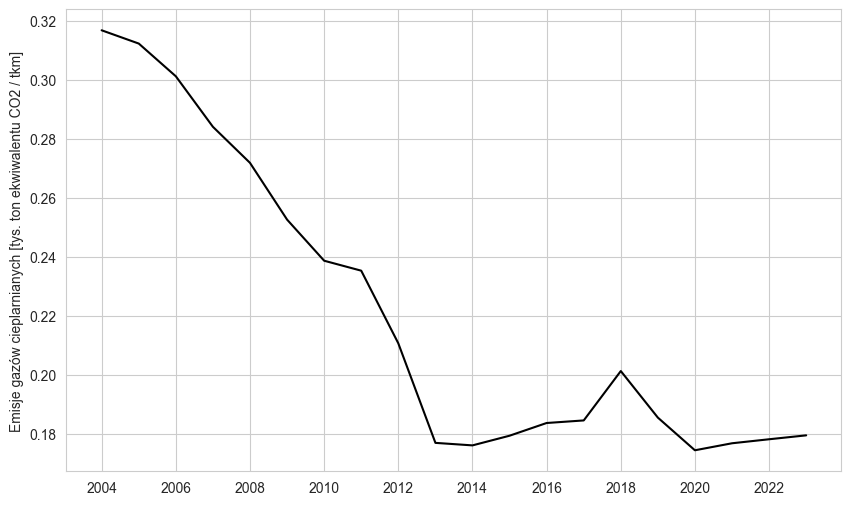

In [68]:
general_plot(
    yearly_data["env_emis_td_prac_przew"],
    file="../figures/env_emis_td_prac_przew.png",
    ylabel="Emisje gazów cieplarnianych [tys. ton ekwiwalentu CO2 / tkm]",
    title=None,
    save_file=True
)